# Notebook 1 - Understanding the Alberta Electricity Market

## Overview

This notebook provides an exploratory analysis of the Alberta electricity market and establishes the operational context for the analyses developed throughout the remainder of the project.

The objective is not to develop predictive models, but to understand the underlying behavior of the market by examining:

* electricity demand and its evolution over time,
* the generation mix and structural changes in supply,
* pool price dynamics,
* the role of generation technologies,
* imports, outages, and system conditions, and
* long-term trends across the study period.

The observations developed in this notebook motivate the hypotheses, feature engineering, and predictive modeling presented in subsequent notebooks.

## 1. Import and Data Validation

### 1.1 Import Libraries and Load Data

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from config import (
    PA_TABLE_PARQUET,
    INTERTIES_HOUR_AHEAD_PARQUET,
    INTERTIE_CAPABILITY_PARQUET,
    GENERATION_PARQUET,
    OUTAGES_PARQUET,
    CALENDAR_FEATURES,
    LOAD_WEATHER_FEATURES,
    MARKET_FEATURES,
    RENEWABLE_WEATHER_FEATURES,
    RANDOM_SEED,
)

# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
np.random.seed(RANDOM_SEED)

# ---------------------------------------------------------------------
# Load processed datasets
# ---------------------------------------------------------------------

pa_hourly = pd.read_parquet(PA_TABLE_PARQUET)
interties_hour_ahead = pd.read_parquet(INTERTIES_HOUR_AHEAD_PARQUET)
intertie_capability = pd.read_parquet(INTERTIE_CAPABILITY_PARQUET)
generation = pd.read_parquet(GENERATION_PARQUET)
outages = pd.read_parquet(OUTAGES_PARQUET)
calendar = pd.read_parquet(CALENDAR_FEATURES)
weather = pd.read_parquet(LOAD_WEATHER_FEATURES)
market = pd.read_parquet(MARKET_FEATURES)
renewables = pd.read_parquet(RENEWABLE_WEATHER_FEATURES)

In [2]:
def show(df, height=400):
    return (
        df.style.set_table_attributes(
            f'style="display:block; max-height:{height}px; overflow-y:auto;"'
        )
    )

### 1.2 Dataset Overview

In [3]:
# ---------------------------------------------------------------------
# Summarize the processed datasets
# ---------------------------------------------------------------------

summary = []

datasets = {
    "pa_hourly": pa_hourly,
    "interties": interties_hour_ahead,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "outages": outages,
    "calendar": calendar,
    "weather": weather,
    "market": market,
    "renewables": renewables,
}

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Start": df["timestamp_utc"].min(),
        "End": df["timestamp_utc"].max(),
        "Duplicate timestamps": df["timestamp_utc"].duplicated().sum(),
        "Missing values": int(df.isna().sum().sum()),
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1e6, 2),
    })

dataset_summary = pd.DataFrame(summary)

dataset_summary

,Dataset,Rows,Columns,Start,End,Duplicate timestamps,Missing values,Memory (MB)
0,pa_hourly,100055,5,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,0,4.00
1,interties,136583,8,2010-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00,0,62786,8.74
2,intertie_capability,100033,9,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,0,7.20
3,generation,100055,61,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,985430,48.83
4,outages,100033,13,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,197686,10.40
5,calendar,100776,46,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0,19.16
6,weather,87672,73,2015-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00,0,110326,45.68
7,market,100055,264,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,739383,185.12
8,renewables,100776,51,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,44295,41.12


In [4]:
# ---------------------------------------------------------------------
# Summarize missing values by dataset
# ---------------------------------------------------------------------

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{name}")

    if missing.empty:
        print("No missing values.")
    else:
        display(
            missing.sort_values(ascending=False).to_frame("Missing")
        )


pa_hourly
No missing values.

interties


,Missing
export_mt,31391
import_mt,31391
hour_ahead_price_forecast,4



intertie_capability
No missing values.

generation


,Missing
gas_fired_steam_system_available,53352
gas_fired_steam_system_generation,53352
gas_fired_steam_maximum_capacity,53352
gas_fired_steam_system_capacity,53352
gas_fired_steam_total_generation,53352
storage_total_generation,51143
storage_system_capacity,51143
storage_system_available,51143
storage_maximum_capacity,51143
storage_system_generation,51143



outages


...

,Missing
load_weighted_heat_index_c,86824
load_weighted_wind_chill_c,23456
load_temperature_change_24h_c,24
load_temperature_change_12h_c,12
load_temperature_change_6h_c,6
load_temperature_change_3h_c,3
load_temperature_change_1h_c,1



market


,Missing
gas_fired_steam_outage,53374
storage_outage,51165
storage_outage_mw,51165
dual_fuel_outage,50037
solar_outage,25678
...,...
ail_ramp_change_1h,1
pool_price_lag_1h,1
pool_price_change_1h,1
spark_spread_lag_1h,1



renewables


,Missing
solar_clear_sky_radiation_ratio,44295


#### Observations

- The processed datasets contain no duplicate timestamps. Differences in temporal coverage between datasets are expected and are examined in the following section.
- The **pa_hourly**, **intertie_capability**, and **calendar** datasets contain no missing values.
- The **hour-ahead price forecast** contains only four missing observations, indicating effectively complete coverage.
- Missing import and export values in the **interties** dataset are concentrated in the Montana intertie and likely reflect historical reporting limitations rather than data quality issues.
- Missing values in the **generation** and **outages** datasets are primarily structural. Technologies such as coal, solar, storage, dual-fuel, and gas-fired steam entered or exited the Alberta generation fleet during the study period, so measurements are unavailable before commissioning or after retirement.
- The **market** feature dataset inherits much of its missingness from the underlying generation and outage datasets. A small number of lagged and rolling features also contain expected missing values at the beginning of the time series where insufficient historical observations are available.
- Missing values in the **weather** dataset are largely expected. The load-weighted heat index is undefined during cold conditions, while the wind chill index is undefined during warmer conditions. Temperature change features contain a small number of missing observations at the beginning of the dataset because previous observations are unavailable.
- The **renewables** dataset contains missing values for the solar clear-sky radiation ratio during nighttime hours when incoming solar radiation is zero, making the ratio undefined.

Overall, the observed missingness is consistent with historical changes in Alberta's generation fleet, feature engineering requirements, and physically undefined quantities, rather than widespread data quality issues.

### 1.3 Validate External Data Coverage

In [5]:
# ---------------------------------------------------------------------
# Validate historical Montana intertie coverage
# ---------------------------------------------------------------------

# Identify the first reported Montana import and export observations.
print(
    interties_hour_ahead.loc[
        interties_hour_ahead["import_mt"].notna(),
        "timestamp_utc",
    ].min()
)

print(
    interties_hour_ahead.loc[
        interties_hour_ahead["export_mt"].notna(),
        "timestamp_utc",
    ].min()
)

# Confirm that no missing values remain after historical reporting begins.
cutoff = pd.Timestamp("2013-08-01 06:00:00+00:00", tz="UTC")

mt_missing = (
    interties_hour_ahead.loc[
        interties_hour_ahead["timestamp_utc"] >= cutoff,
        ["import_mt", "export_mt"],
    ]
    .isna()
    .sum()
)

print(mt_missing)

2013-08-01 06:00:00+00:00
2013-08-01 06:00:00+00:00
import_mt    0
export_mt    0
dtype: int64


#### Montana Intertie Reporting

The **import_mt** and **export_mt** variables are missing prior to August 2013. Investigation confirmed that these missing values are expected rather than indicative of data quality issues.

The Montana-Alberta Tie Line (MATL) entered commercial service in 2013, and AESO public reporting of Montana intertie schedules and transfer capability began around the commissioning period. Consequently, observations prior to this date represent the absence of an operational and publicly reported intertie rather than missing data.

Both variables contain complete observations beginning on **2013-08-01 06:00:00 UTC**, consistent with the start of historical reporting.

In [6]:
# ---------------------------------------------------------------------
# Validate generation dataset coverage by fuel category
# ---------------------------------------------------------------------

generation_coverage = []

for col in generation.columns:
    if col == "timestamp_utc":
        continue

    non_missing = generation.loc[
        generation[col].notna(),
        "timestamp_utc",
    ]

    generation_coverage.append({
        "Column": col,
        "First non-missing": non_missing.min(),
        "Last non-missing": non_missing.max(),
        "Missing": generation[col].isna().sum(),
    })

generation_coverage = (
    pd.DataFrame(generation_coverage)
    .sort_values("First non-missing")
)

show(generation_coverage)

,Column,First non-missing,Last non-missing,Missing
0,coal_system_generation,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,16800
28,other_system_available,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
58,total_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
32,wind_system_available,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
33,coal_system_capacity,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,16800
34,cogeneration_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
35,combined_cycle_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
38,hydro_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
39,other_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
40,simple_cycle_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0


#### Generation Dataset Coverage

Missingness in the generation dataset is highly structured by fuel category and reflects changes in Alberta's generation fleet and AESO reporting over time rather than random data quality issues.

- Coal generation variables terminate in July 2024, consistent with the completion of Alberta's coal phase-out and coal-to-gas conversions.
- Solar generation first appears in December 2017, while storage generation begins in November 2020, reflecting the commissioning of these technologies and their inclusion in AESO reporting.
- Dual-fuel variables are available from March 2018 through July 2024. The observed coverage likely reflects changes in AESO fuel classifications and the retirement or conversion of dual-fuel assets.
- Gas-fired steam variables first appear in February 2021. This timing is more consistent with changes in AESO reporting or fuel classification than with the physical introduction of gas-fired steam generation, which existed prior to the study period.
- Within each fuel category, all generation, available capacity, installed capacity, and maximum capacity variables share identical temporal coverage, indicating that missing values correspond to periods where the category was not reported rather than isolated missing observations.

Overall, the generation dataset exhibits expected structural missingness that aligns with historical changes in Alberta's electricity system and AESO reporting practices. These values are therefore treated as structurally unavailable rather than randomly missing.

### 1.4 Merge

In [7]:
# ---------------------------------------------------------------------
# Configure the master dataset merge
# ---------------------------------------------------------------------

merge_key = "timestamp_utc"

# Calendar is the canonical source for timestamp-derived features.
# Placing it first preserves its values when identical calendar columns
# also appear in another feature dataset.
datasets = {
    "calendar": calendar,
    "market": market,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "weather": weather,
    "renewables": renewables,
}

duplicate_columns_removed = []


# ---------------------------------------------------------------------
# Validate merge keys and timestamp uniqueness
# ---------------------------------------------------------------------

for dataset_name, df in datasets.items():

    if merge_key not in df.columns:
        raise KeyError(
            f"{merge_key!r} is missing from dataset "
            f"{dataset_name!r}."
        )

    duplicate_timestamps = df[merge_key].duplicated().sum()

    if duplicate_timestamps:
        raise ValueError(
            f"Dataset {dataset_name!r} contains "
            f"{duplicate_timestamps:,} duplicate timestamps."
        )


# ---------------------------------------------------------------------
# Initialize the master dataset with the canonical calendar table
# ---------------------------------------------------------------------

first_name, first_df = next(iter(datasets.items()))

master = (
    first_df
    .sort_values(merge_key)
    .copy()
)


# ---------------------------------------------------------------------
# Merge feature datasets and reconcile overlapping columns
# ---------------------------------------------------------------------

for dataset_name, df in list(datasets.items())[1:]:

    incoming = (
        df
        .sort_values(merge_key)
        .copy()
    )

    overlapping_columns = sorted(
        (set(master.columns) & set(incoming.columns))
        - {merge_key}
    )

    columns_to_drop = []

    for column in overlapping_columns:

        comparison = (
            master[[merge_key, column]]
            .merge(
                incoming[[merge_key, column]],
                on=merge_key,
                how="inner",
                suffixes=("_master", "_incoming"),
                validate="one_to_one",
            )
        )

        master_col = f"{column}_master"
        incoming_col = f"{column}_incoming"

        values_match = (
            comparison[master_col].eq(
                comparison[incoming_col]
            )
            | (
                comparison[master_col].isna()
                & comparison[incoming_col].isna()
            )
        )

        if values_match.all():

            # Retain the version already present in the master dataset.
            columns_to_drop.append(column)

            duplicate_columns_removed.append(
                {
                    "incoming_dataset": dataset_name,
                    "column_removed": column,
                }
            )

        else:

            discrepancies = comparison.loc[
                ~values_match.fillna(False),
                [
                    merge_key,
                    master_col,
                    incoming_col,
                ],
            ]

            print(
                f"\nConflicting duplicate column: {column!r}"
                f"\nIncoming dataset: {dataset_name!r}"
                f"\nMismatched rows: {len(discrepancies):,}"
            )

            display(discrepancies.head(50))

            raise ValueError(
                f"Column {column!r} exists in both master and "
                f"{dataset_name!r}, but the values are not identical."
            )

    incoming = incoming.drop(
        columns=columns_to_drop
    )

    # Retain only timestamps covered by every required dataset.
    master = master.merge(
        incoming,
        on=merge_key,
        how="inner",
        validate="one_to_one",
    )


# ---------------------------------------------------------------------
# Finalize and audit the master dataset
# ---------------------------------------------------------------------

master = (
    master
    .sort_values(merge_key)
    .reset_index(drop=True)
)

suffixed_columns = [
    column
    for column in master.columns
    if column.endswith("_x")
    or column.endswith("_y")
]

calendar_columns = [
    column
    for column in calendar.columns
    if column != merge_key
]

missing_calendar_columns = [
    column
    for column in calendar_columns
    if column not in master.columns
]

print(f"Shape: {master.shape}")
print(f"Start: {master[merge_key].min()}")
print(f"End:   {master[merge_key].max()}")

print(
    f"Duplicate timestamps: "
    f"{master[merge_key].duplicated().sum()}"
)

print(
    f"Missing values: "
    f"{master.isna().sum().sum():,}"
)

print(
    f"Identical duplicate columns removed: "
    f"{len(duplicate_columns_removed)}"
)

print(
    f"Calendar columns retained: "
    f"{len(calendar_columns) - len(missing_calendar_columns)}"
    f"/{len(calendar_columns)}"
)

print(
    f"Unexpected suffixed columns: "
    f"{len(suffixed_columns)}"
)

if duplicate_columns_removed:

    duplicate_audit = pd.DataFrame(
        duplicate_columns_removed
    )

    display(duplicate_audit)

if missing_calendar_columns:
    raise ValueError(
        "The following canonical calendar columns are missing "
        f"from master: {missing_calendar_columns}"
    )

if suffixed_columns:
    raise ValueError(
        "Unexpected merge suffix columns remain: "
        f"{suffixed_columns}"
    )

Shape: (87665, 452)
Start: 2015-01-01 07:00:00+00:00
End:   2024-12-31 23:00:00+00:00
Duplicate timestamps: 0
Missing values: 1,236,776
Identical duplicate columns removed: 47
Calendar columns retained: 45/45
Unexpected suffixed columns: 0


,incoming_dataset,column_removed
0,market,day_name_alberta
1,market,day_of_month_alberta
2,market,day_of_week_alberta
3,market,day_of_week_cos
4,market,day_of_week_sin
5,market,day_of_year_alberta
6,market,day_of_year_cos
7,market,day_of_year_sin
8,market,holiday_name
9,market,hour_alberta


In [8]:
# ---------------------------------------------------------------------
# Audit missingness in the master dataset
# ---------------------------------------------------------------------

missing_audit = (
    master
    .isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
)

missing_audit["missing_pct"] = (
    missing_audit["missing_rows"]
    / len(master)
    * 100
)

missing_audit = (
    missing_audit
    .query("missing_rows > 0")
    .sort_values(
        ["missing_pct", "missing_rows"],
        ascending=False,
    )
)

print(
    f"Columns with missing values: "
    f"{len(missing_audit):,} / {master.shape[1]:,}"
)

display(
    missing_audit.head(25).style.set_table_attributes(
        'style="display:block; max-height:400px; overflow:auto;"'
    )
)

Columns with missing values: 202 / 452


,missing_rows,missing_pct
load_weighted_heat_index_c,86817,99.032681
gas_fired_steam_outage,53352,60.858952
gas_fired_steam_system_generation,53352,60.858952
gas_fired_steam_total_generation,53352,60.858952
gas_fired_steam_system_available,53352,60.858952
gas_fired_steam_system_capacity,53352,60.858952
gas_fired_steam_maximum_capacity,53352,60.858952
storage_outage,51143,58.339132
storage_outage_mw,51143,58.339132
storage_system_generation,51143,58.339132


#### Merge Missingness Audit

The remaining missing values in the master dataset are consistent with the characteristics of the underlying source datasets and the feature engineering process. No evidence of unexpected missingness was identified following the merge.

- **Historical source coverage:** Gas-fired steam, storage, dual-fuel, solar, and coal variables contain substantial blocks of missing values because these technologies were not consistently reported across the full study period or their reporting began after the start of the master dataset. These missing values reflect historical reporting boundaries rather than data quality issues.

- **Conditionally defined weather variables:**
  - **load_weighted_heat_index_c** is approximately 99% missing because the heat index is only defined for temperatures of at least **26.7°C** with relative humidity of at least **40%**.
  - **load_weighted_wind_chill_c** is approximately 27% missing because wind chill is only defined for temperatures at or below **10°C** with wind speeds of at least **4.8 km/h**.
  - These variables are intentionally undefined outside their applicable meteorological conditions and should not be interpreted as ordinary missing observations.

- **Solar clear-sky radiation ratio:** Missing values are concentrated during nighttime and other periods when clear-sky solar radiation is zero, making the ratio mathematically undefined.

- **Lagged and rolling features:** A small number of missing observations occur at the beginning of the dataset as an expected consequence of feature engineering. For example, a 24-hour lag produces 24 missing observations, while a 168-hour lag produces 168 missing observations.

- **Minor isolated gaps:** Several variables contain only one or a few missing observations. Relative to the size of the dataset, these are negligible and can be handled during construction of the model-ready sample.

Overall, the missing values present in the merged dataset are consistent with historical reporting boundaries, physically or mathematically undefined quantities, and expected feature engineering artifacts. No unexpected missingness was introduced during the merge process.

## Section 2 — Long-Term Evolution of Alberta's Electricity Market

Alberta's electricity market changed substantially over the study period. Electricity demand increased, the generation mix shifted away from coal toward natural gas and renewables, and new technologies such as utility-scale solar and battery storage entered the system.

This section examines how the market evolved at an annual level before exploring shorter-term operational behaviour in subsequent sections. Annual results are interpreted cautiously where only partial-year observations are available.

### 2.1 How Has Electricty Demand Changed?

In [9]:
# ---------------------------------------------------------------------
# Summarize annual electricity demand
# ---------------------------------------------------------------------

load_col = "ail_mw"

annual_load = (
    master.groupby("year_alberta")[load_col]
    .agg(
        average_load_mw="mean",
        median_load_mw="median",
        peak_load_mw="max",
        minimum_load_mw="min",
    )
)

annual_load["annual_energy_twh"] = (
    master.groupby("year_alberta")[load_col].sum() / 1_000_000
)

annual_load["average_load_growth_pct"] = (
    annual_load["average_load_mw"].pct_change() * 100
)

annual_load.round(2)

,average_load_mw,median_load_mw,peak_load_mw,minimum_load_mw,annual_energy_twh,average_load_growth_pct
year_alberta,,,,,,
2015,9161.75,9168.0,11229,7203,80.26,NaN
2016,9057.37,9080.0,11458,6595,79.56,-1.14
2017,9426.08,9401.0,11473,7600,82.57,4.07
2018,9740.86,9749.5,11697,7819,85.33,3.34
2019,9694.67,9677.0,11471,8024,84.93,-0.47
2020,9462.05,9437.0,11698,7579,83.11,-2.40
2021,9727.59,9653.5,11729,7976,85.21,2.81
2022,9882.61,9851.0,12193,8110,86.57,1.59
2023,9850.81,9847.0,11572,7873,86.29,-0.32


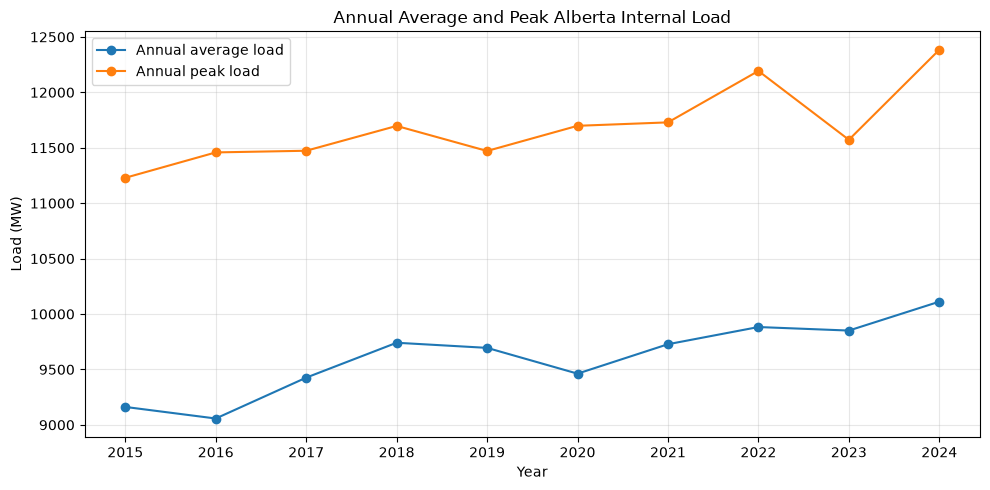

In [10]:
# ---------------------------------------------------------------------
# Visualize long-term demand trends
# ---------------------------------------------------------------------

plot_df = annual_load.loc[:2025]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df.index,
    plot_df["average_load_mw"],
    marker="o",
    label="Annual average load",
)

ax.plot(
    plot_df.index,
    plot_df["peak_load_mw"],
    marker="o",
    label="Annual peak load",
)

ax.set_title("Annual Average and Peak Alberta Internal Load")
ax.set_xlabel("Year")
ax.set_ylabel("Load (MW)")
ax.set_xticks(plot_df.index)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

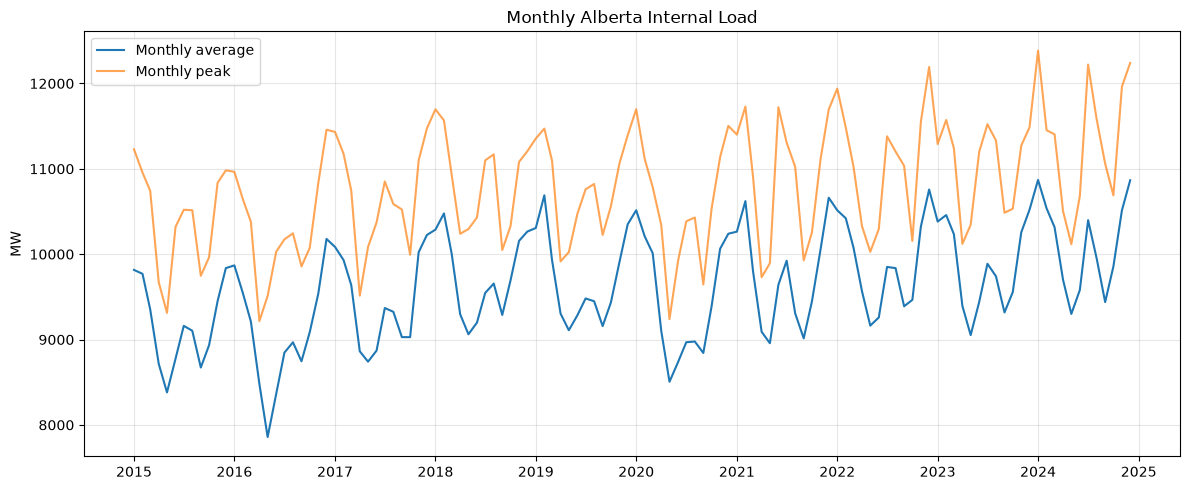

In [11]:
# ---------------------------------------------------------------------
# Visualize monthly demand evolution
# ---------------------------------------------------------------------

monthly_load = (
    master.set_index("timestamp_utc")[load_col]
    .resample("MS")
    .agg(["mean", "max"])
    .rename(
        columns={
            "mean": "average_load_mw",
            "max": "peak_load_mw",
        }
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_load.index,
    monthly_load["average_load_mw"],
    label="Monthly average",
)

ax.plot(
    monthly_load.index,
    monthly_load["peak_load_mw"],
    alpha=0.7,
    label="Monthly peak",
)

ax.set_title("Monthly Alberta Internal Load")
ax.set_xlabel("")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Electricity Demand

Alberta Internal Load exhibits a clear long-term upward trend over the study period. Excluding the partial year of 2026, average demand increased from **9.16 GW** in 2015 to **10.32 GW** in 2025, while annual electricity consumption rose from **80.3 TWh** to **90.4 TWh**. Although demand growth was not uniform—with modest declines occurring in 2016, 2019, 2020, and 2023—the overall trajectory is upward, culminating in record average demand during 2024 and 2025.

Peak demand also increased substantially, rising from **11.23 GW** in 2015 to **12.79 GW** in 2025. Annual peak loads exhibit greater year-to-year variability than annual average demand because they are driven by relatively infrequent periods of extreme system conditions. Minimum demand also increased over the study period, suggesting that growth has occurred not only during peak periods but across the system's baseline load.

The monthly demand profile reveals a strong seasonal pattern. Average and peak loads are generally highest during the winter months (November through February) and lowest during the spring and early autumn shoulder seasons. Recent summers, particularly 2024 and 2025, also exhibit elevated demand relative to earlier years, suggesting that summer demand may be becoming increasingly important.

Alberta's demand has increased steadily despite several temporary declines, while its seasonal structure has remained remarkably stable. This implies that future scarcity is likely to depend less on changing demand patterns than on how effectively the evolving generation fleet can meet this higher baseline load.

### 2.2 How Has Generation Mix Changed?

In [12]:
# ---------------------------------------------------------------------
# Define generation categories for analysis
# ---------------------------------------------------------------------

GENERATION_COLUMNS = {
    "Coal": "coal_system_generation",
    "Cogeneration": "cogeneration_system_generation",
    "Combined Cycle": "combined_cycle_system_generation",
    "Dual Fuel": "dual_fuel_system_generation",
    "Gas-Fired Steam": "gas_fired_steam_system_generation",
    "Hydro": "hydro_system_generation",
    "Other": "other_system_generation",
    "Simple Cycle": "simple_cycle_system_generation",
    "Solar": "solar_system_generation",
    "Storage": "storage_system_generation",
    "Wind": "wind_system_generation",
}

In [13]:
# ---------------------------------------------------------------------
# Summarize annual generation by fuel category
# ---------------------------------------------------------------------

annual_generation_gwh = (
    master
    .groupby("year_alberta")[list(GENERATION_COLUMNS.values())]
    .sum(min_count=1)
    .div(1_000)
    .rename(
        columns={
            column: fuel
            for fuel, column in GENERATION_COLUMNS.items()
        }
    )
)

# Exclude the partial 2026 calendar year.
annual_generation_gwh = annual_generation_gwh.loc[:2025]

display(annual_generation_gwh.round(1))

,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
year_alberta,,,,,,,,,,,
2015,39392.8,10357.8,5033.8,NaN,NaN,1708.2,570.3,703.8,NaN,NaN,4089.2
2016,38424.0,10427.4,5943.7,NaN,NaN,1733.0,609.1,741.0,NaN,NaN,4405.1
2017,37138.6,10933.4,7246.4,NaN,NaN,1887.2,515.8,888.1,0.1,NaN,4486.3
2018,28523.0,14066.5,9187.4,473.9,NaN,1861.2,651.6,2486.5,22.4,NaN,4104.1
2019,27199.9,14227.0,9652.2,708.6,NaN,1995.6,623.2,2815.2,20.3,NaN,4115.8
2020,20164.0,13795.4,10085.5,2243.3,NaN,2035.3,569.7,2453.8,86.3,0.1,6079.4
2021,15404.8,14321.1,9776.1,2606.6,3616.1,1818.2,697.5,3562.1,477.0,0.6,6132.9
2022,9711.9,13907.8,10703.7,597.9,10509.6,1922.6,651.1,3542.2,1163.9,0.7,7315.3
2023,6519.6,13515.3,10884.4,4038.7,10602.5,1688.8,698.0,2436.1,2311.2,1.8,10283.9


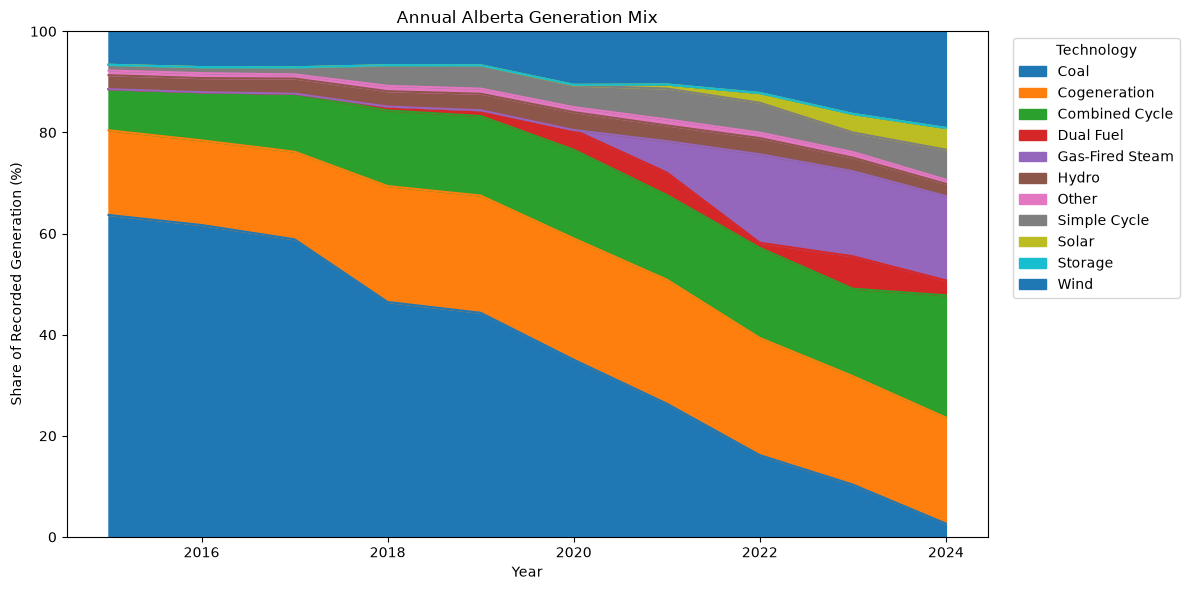

In [14]:
# ---------------------------------------------------------------------
# Visualize changes in the annual generation mix
# ---------------------------------------------------------------------

annual_generation_share = (
    annual_generation_gwh
    .div(annual_generation_gwh.sum(axis=1), axis=0)
    .mul(100)
)

fig, ax = plt.subplots(figsize=(12, 6))

annual_generation_share.plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Annual Alberta Generation Mix")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Recorded Generation (%)")
ax.set_ylim(0, 100)

ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Generation Mix

Alberta's generation portfolio underwent a substantial structural transformation over the study period. Coal-fired generation declined from approximately **64%** of recorded annual generation in 2015 to negligible levels by 2024, reflecting Alberta's transition away from coal-fired electricity generation. Over the same period, combined-cycle natural gas expanded from approximately **8%** to **24%** of annual generation, while cogeneration remained relatively stable, consistently contributing between **21%** and **25%**. Together with simple-cycle and gas-fired steam generation, natural gas technologies became the dominant source of electricity generation by the end of the study period.

Renewable generation also expanded considerably. Wind generation increased from **6.6%** of annual generation in 2015 to approximately **19%** by 2024, while utility-scale solar generation grew from effectively zero to more than **4%** as new projects entered service. Hydroelectric generation remained relatively stable at approximately **2–3%** of annual generation throughout the study period, while energy storage contributed only a negligible share of recorded generation.

Although total generation shifted dramatically toward natural gas and renewables, these results alone do not indicate whether reliability improved. Later analyses investigate whether the new generation mix reduced or increased Alberta's exposure to scarcity pricing.

> **Reporting note:** *Dual Fuel* refers to generating units capable of operating on both coal and natural gas during Alberta's transition away from coal-fired generation. Following completion of the off-coal transition in 2024, the AESO discontinued separate reporting of the **Coal** and **Dual Fuel** generation categories as the remaining units completed conversion to natural gas technologies. Consequently, generation shares reported after this reporting change are not directly comparable with earlier years because the underlying technology classifications differ.


### 2.3 How has generation capacity changed?

> **Reporting Note:** The AESO Generation dataset reports several complementary measures for each fuel type. **System Generation** represents electricity delivered to the Alberta grid and is used in the previous section to analyze the generation mix. This section uses **Maximum Capacity**, which represents the broadest reported generation capability by fuel type and is intended to illustrate long-term changes in Alberta's generation fleet. **System Capacity** represents the maximum generation capability available to the Alberta grid, while **Total Generation** includes both grid-connected and behind-the-fence generation.


In [15]:
# ---------------------------------------------------------------------
# Define AESO maximum-capacity variables by technology
# ---------------------------------------------------------------------

CAPACITY_COLUMNS = {
    "Coal": "coal_maximum_capacity",
    "Cogeneration": "cogeneration_maximum_capacity",
    "Combined Cycle": "combined_cycle_maximum_capacity",
    "Simple Cycle": "simple_cycle_maximum_capacity",
    "Gas-Fired Steam": "gas_fired_steam_maximum_capacity",
    "Hydro": "hydro_maximum_capacity",
    "Other": "other_maximum_capacity",
    "Solar": "solar_maximum_capacity",
    "Storage": "storage_maximum_capacity",
    "Wind": "wind_maximum_capacity",
}

TOTAL_MAXIMUM_CAPACITY_COLUMN = "total_maximum_capacity"

In [16]:
# ---------------------------------------------------------------------
# Summarize year-end maximum generation capacity by technology
# ---------------------------------------------------------------------

capacity_columns = [
    *CAPACITY_COLUMNS.values(),
    TOTAL_MAXIMUM_CAPACITY_COLUMN,
]

year_end_capacity = (
    master
    .sort_values("timestamp_utc")
    .groupby("year_alberta", group_keys=False)
    .tail(1)
    .set_index("year_alberta")
)

annual_capacity_mw = (
    year_end_capacity[capacity_columns]
    .rename(
        columns={
            **{
                column: technology
                for technology, column in CAPACITY_COLUMNS.items()
            },
            TOTAL_MAXIMUM_CAPACITY_COLUMN: "Reported Total",
        }
    )
)

display(annual_capacity_mw.round(1))

,Coal,Cogeneration,Combined Cycle,Simple Cycle,Gas-Fired Steam,Hydro,Other,Solar,Storage,Wind,Reported Total
year_alberta,,,,,,,,,,,
2015,6289.0,4552.0,1758.0,946.0,NaN,894.0,386.0,NaN,NaN,1463.0,16288.0
2016,6299.0,4779.0,1745.0,866.0,NaN,894.0,395.0,NaN,NaN,1445.0,16423.0
2017,6003.0,4986.0,1745.0,866.0,NaN,894.0,392.0,15.0,NaN,1445.0,16346.0
2018,5568.0,4987.0,1790.0,871.0,NaN,894.0,381.0,15.0,NaN,1445.0,16106.0
2019,5183.0,5093.0,1790.0,855.0,NaN,894.0,381.0,15.0,NaN,1781.0,16532.0
2020,4132.0,5131.0,1798.0,1076.0,NaN,894.0,381.0,107.0,30.0,1781.0,16270.0
2021,2530.0,5247.0,1798.0,1182.0,1981.0,894.0,382.0,736.0,50.0,2269.0,17224.0
2022,820.0,5285.0,1852.0,1190.0,2609.0,894.0,402.0,1138.0,70.0,3618.0,18344.0
2023,820.0,5304.0,3052.0,909.0,2609.0,894.0,402.0,1650.0,190.0,4481.0,20777.0


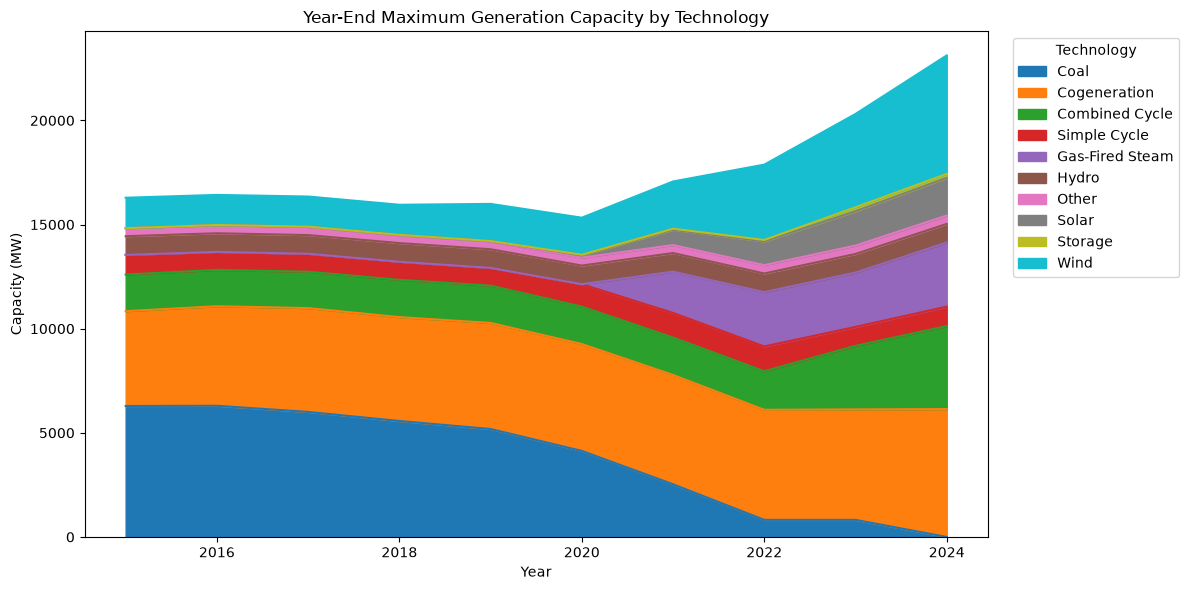

In [17]:
# ---------------------------------------------------------------------
# Visualize changes in maximum generation capacity
# ---------------------------------------------------------------------

technology_columns = list(CAPACITY_COLUMNS.keys())

fig, ax = plt.subplots(figsize=(12, 6))

annual_capacity_mw[technology_columns].plot(
    kind="area",
    stacked=True,
    ax=ax,
)

ax.set_title("Year-End Maximum Generation Capacity by Technology")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity (MW)")
ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

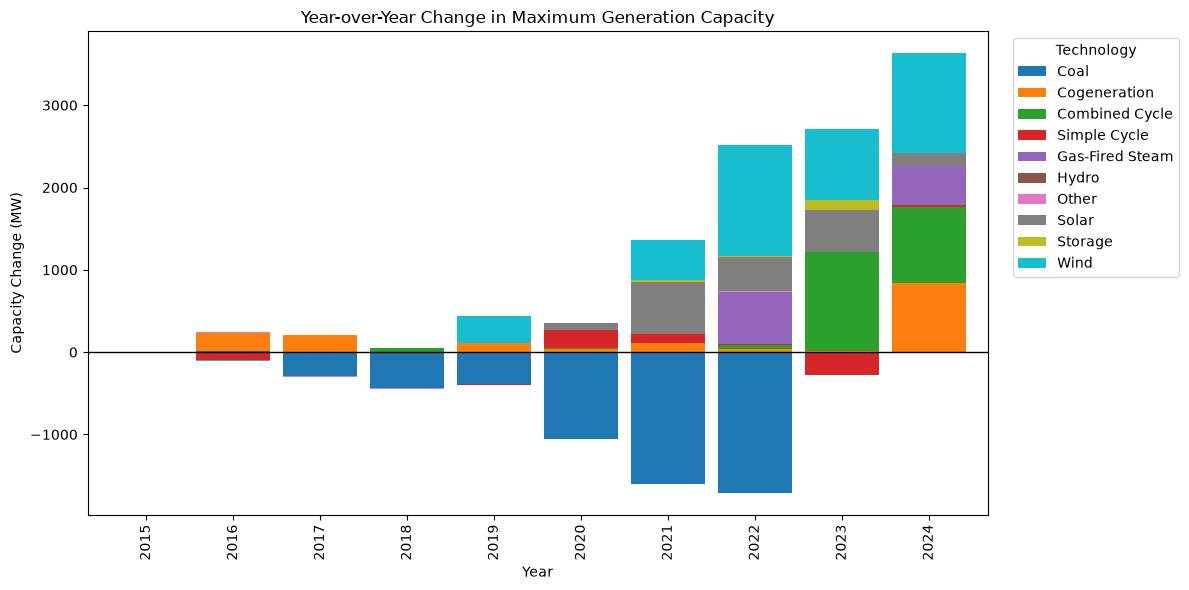

In [18]:
# ---------------------------------------------------------------------
# Visualize year-over-year changes in maximum generation capacity
# ---------------------------------------------------------------------

capacity_change_mw = annual_capacity_mw[
    technology_columns
].diff()

fig, ax = plt.subplots(figsize=(12, 6))

capacity_change_mw.plot(
    kind="bar",
    stacked=True,
    width=0.85,
    ax=ax,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_title("Year-over-Year Change in Maximum Generation Capacity")
ax.set_xlabel("Year")
ax.set_ylabel("Capacity Change (MW)")

ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

#### Maximum Generation Capcity:

Alberta's reported maximum generation capacity increased substantially over the study period, rising from approximately 16.3 GW at year-end 2015 to 23.1 GW at year-end 2024. This expansion occurred alongside a major restructuring of the generation fleet, characterized by declining coal capacity, expanding natural gas capability, and rapid growth in wind and solar.

Coal capacity declined from approximately 6.3 GW in 2015 to 0.8 GW by the end of 2022 and remained at that level through 2023. The Coal category was no longer separately reported at year-end 2024. Over the same period, combined-cycle capacity increased from approximately 1.8 GW to 4.0 GW, with particularly large additions during 2023 and 2024. Cogeneration capacity also expanded from approximately 4.6 GW to 6.1 GW, while simple-cycle capacity remained comparatively stable near 0.9–1.2 GW across most of the study period.

Renewable capacity grew rapidly. Wind capacity increased from approximately 1.5 GW in 2015 to 5.7 GW in 2024, while solar expanded from negligible levels in 2017 to approximately 1.8 GW by 2024. Hydroelectric capacity remained unchanged at approximately 0.9 GW, and reported battery-storage capacity increased from 30 MW in 2020 to 190 MW by 2023, remaining at that level in 2024.

Gas-fired steam capacity first appeared as a distinct reporting category in 2021, increasing from approximately 2.0 GW to 3.1 GW by 2024. This change should not be interpreted entirely as newly constructed capacity, because changes in AESO fuel classifications also affected how existing thermal assets were reported.

Capacity expanded much faster than demand, yet later sections show scarcity became more common after 2021. This immediately suggests that installed capacity alone cannot explain market reliability and motivates investigation of operational flexibility, outages, and generator availability.

> **Reporting note:** Values represent the final reported Maximum Capacity observation in each calendar year. The AESO defines Maximum Capacity as the broadest reported generation capability, including capability associated with behind-the-fence generation. Changes in the Coal, Dual Fuel, and Gas-Fired Steam categories reflect both physical fleet changes and evolving fuel classifications. Consequently, technology-level changes should not always be interpreted as one-for-one additions or retirements.

### 2.4 How has intertie usage changed?

In [19]:
# ---------------------------------------------------------------------
# Summarize annual intertie imports and exports
# ---------------------------------------------------------------------

imports_col = "total_imports_mw"
exports_col = "total_exports_mw"
net_imports_col = "net_imports_mw"

annual_interties = (
    master.groupby("year_alberta").agg(
        average_total_imports_mw=(
            imports_col,
            "mean",
        ),
        peak_total_import_mw=(
            imports_col,
            "max",
        ),
        total_import_energy_gwh=(
            imports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_total_exports_mw=(
            exports_col,
            "mean",
        ),
        total_export_energy_gwh=(
            exports_col,
            lambda series: series.sum(min_count=1) / 1_000,
        ),
        average_net_imports_mw=(
            net_imports_col,
            "mean",
        ),
        peak_net_imports_mw=(
            net_imports_col,
            "max",
        ),
        minimum_net_imports_mw=(
            net_imports_col,
            "min",
        ),
        net_importing_hours=(
            "is_net_importing",
            "sum",
        ),
        net_exporting_hours=(
            "is_net_exporting",
            "sum",
        ),
    )
)

annual_interties["net_import_energy_gwh"] = (
    annual_interties["total_import_energy_gwh"]
    - annual_interties["total_export_energy_gwh"]
)

display(annual_interties.round(2))

,average_total_imports_mw,peak_total_import_mw,total_import_energy_gwh,average_total_exports_mw,total_export_energy_gwh,average_net_imports_mw,peak_net_imports_mw,minimum_net_imports_mw,net_importing_hours,net_exporting_hours,net_import_energy_gwh
year_alberta,,,,,,,,,,,
2015,124.57,1002.0,1091.22,74.26,650.55,50.30,1002.0,-877.0,4151,2982,440.67
2016,49.52,769.0,435.02,98.67,866.74,-49.15,729.0,-935.0,2408,3749,-431.72
2017,147.79,998.0,1294.66,116.62,1021.61,31.17,998.0,-935.0,3104,4363,273.05
2018,387.42,1092.0,3393.79,83.40,730.60,304.02,1092.0,-1010.0,6390,1890,2663.19
2019,243.43,1154.0,2132.42,69.65,610.13,173.78,1154.0,-939.0,6368,1765,1522.29
2020,451.45,1118.0,3965.51,11.13,97.80,440.31,1118.0,-332.0,8387,75,3867.71
2021,473.81,1059.0,4150.55,15.01,131.46,458.80,1022.0,-532.0,8550,150,4019.09
2022,484.41,983.0,4243.42,71.95,630.31,412.46,983.0,-939.0,7810,942,3613.11
2023,248.57,888.0,2177.47,247.62,2169.12,0.95,888.0,-1026.0,5243,3466,8.35


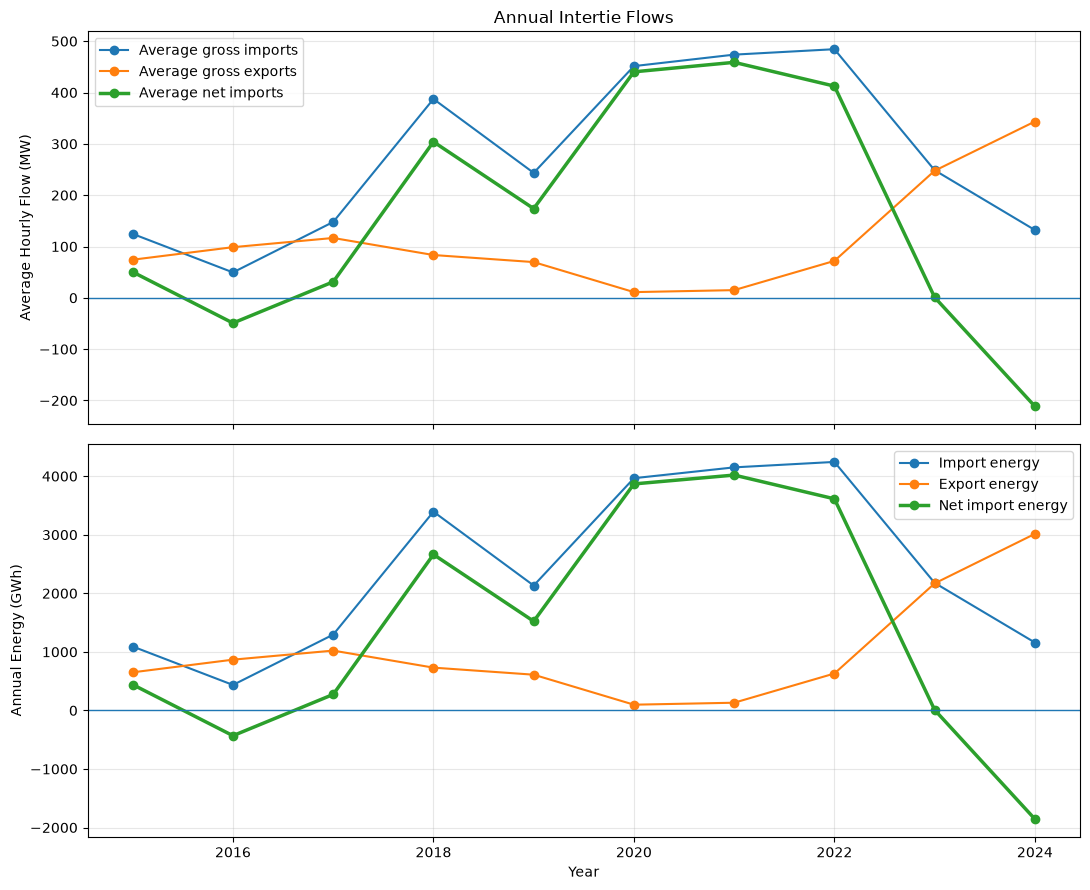

In [20]:
# ---------------------------------------------------------------------
# Visualize annual intertie flows and energy balances
# ---------------------------------------------------------------------

plot_df = annual_interties.copy()

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 9),
    sharex=True,
)

# Average hourly power flows.
axes[0].plot(
    plot_df.index,
    plot_df["average_total_imports_mw"],
    marker="o",
    label="Average gross imports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_total_exports_mw"],
    marker="o",
    label="Average gross exports",
)

axes[0].plot(
    plot_df.index,
    plot_df["average_net_imports_mw"],
    marker="o",
    linewidth=2.5,
    label="Average net imports",
)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("Annual Intertie Flows")
axes[0].set_ylabel("Average Hourly Flow (MW)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Annual imported, exported, and net energy.
axes[1].plot(
    plot_df.index,
    plot_df["total_import_energy_gwh"],
    marker="o",
    label="Import energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["total_export_energy_gwh"],
    marker="o",
    label="Export energy",
)

axes[1].plot(
    plot_df.index,
    plot_df["net_import_energy_gwh"],
    marker="o",
    linewidth=2.5,
    label="Net import energy",
)

axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Annual Energy (GWh)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ---------------------------------------------------------------------
# Summarize imports relative to Alberta Internal Load
# ---------------------------------------------------------------------

imports_share_of_load = (
    master[imports_col]
    / master[load_col]
    * 100
)

annual_import_share = (
    imports_share_of_load
    .groupby(master["year_alberta"])
    .agg(
        average_import_share_pct="mean",
        median_import_share_pct="median",
        p95_import_share_pct=lambda series: series.quantile(0.95),
    )
)

display(annual_import_share.round(2))

,average_import_share_pct,median_import_share_pct,p95_import_share_pct
year_alberta,,,
2015,1.30,0.47,6.27
2016,0.55,0.00,3.13
2017,1.66,0.00,9.18
2018,4.03,3.16,10.24
2019,2.53,1.66,8.86
2020,4.82,4.17,10.72
2021,4.82,4.70,8.53
2022,4.90,5.06,8.73
2023,2.54,2.16,5.81


#### Intertie Flows:

Alberta's intertie usage changed markedly over the study period. Between 2015 and 2017, the province alternated between modest net importing and net exporting positions, with annual net energy exchanges remaining relatively balanced. Beginning in 2018, imports increased substantially. Net import energy reached approximately **2.7 TWh** in 2018 and peaked at **4.0 TWh** in 2021, when Alberta was a net importer during **8,550 hours** and recorded average net imports of approximately **459 MW**.

This pattern reversed after 2021. Net import energy declined during 2022, while exports increased significantly during 2023 and 2024. In 2023, imports and exports were nearly balanced, resulting in only **8 GWh** of net import energy. By 2024, Alberta had become a net exporter on an annual basis, recording approximately **1.9 TWh** of net export energy, average net exports of approximately **211 MW**, and more net exporting hours (**5,665**) than net importing hours (**2,937**).

Although Alberta's annual trade position changed substantially, the system continued to experience large hourly power flows in both directions. Peak hourly imports remained between approximately **700 MW** and **1,150 MW** throughout the study period, while peak net exports also remained substantial. Consequently, annual averages should not be interpreted as indicating one-way intertie usage; Alberta continued to both import and export electricity throughout the period, with the balance shifting over time.

Alberta transitioned from net importer to net exporter despite increasing renewable penetration and continued demand growth. This raises an important question: are interties primarily responding to Alberta's internal conditions, or are they increasingly being driven by opportunities in neighbouring markets?

> **Question:** coal declines, renewables, other generation sources rise, why is alberta able to be a net exporter now? why/when were they more reliant on imports?

### 2.5 Section 2 summary table


In [22]:
# ---------------------------------------------------------------------
# Summarize key structural changes over the study period
# ---------------------------------------------------------------------

first_year = 2015
final_year = 2024

section_2_summary = pd.DataFrame({
    "metric": [
        "Average load",
        "Peak load",
        "Annual electricity consumption",
        "Coal share of recorded generation",
        "Wind share of recorded generation",
        "Maximum generation capacity",
        "Average net imports",
        "Net import energy",
    ],
    f"{first_year}": [
        annual_load.loc[first_year, "average_load_mw"],
        annual_load.loc[first_year, "peak_load_mw"],
        annual_load.loc[first_year, "annual_energy_twh"],
        annual_generation_share.loc[first_year, "Coal"],
        annual_generation_share.loc[first_year, "Wind"],
        annual_capacity_mw.loc[first_year, "Reported Total"],
        annual_interties.loc[first_year, "average_net_imports_mw"],
        annual_interties.loc[first_year, "net_import_energy_gwh"],
    ],
    f"{final_year}": [
        annual_load.loc[final_year, "average_load_mw"],
        annual_load.loc[final_year, "peak_load_mw"],
        annual_load.loc[final_year, "annual_energy_twh"],
        annual_generation_share.loc[final_year, "Coal"],
        annual_generation_share.loc[final_year, "Wind"],
        annual_capacity_mw.loc[final_year, "Reported Total"],
        annual_interties.loc[final_year, "average_net_imports_mw"],
        annual_interties.loc[final_year, "net_import_energy_gwh"],
    ],
    "unit": [
        "MW",
        "MW",
        "TWh",
        "%",
        "%",
        "MW",
        "MW",
        "GWh",
    ],
})

section_2_summary["change"] = (
    section_2_summary[str(final_year)]
    - section_2_summary[str(first_year)]
)

display(
    section_2_summary.style.format({
        "2015": "{:,.2f}",
        "2024": "{:,.2f}",
        "change": "{:+,.2f}",
    })
)

,metric,2015,2024,unit,change
0,Average load,"9,161.75","10,111.42",MW,+949.67
1,Peak load,"11,229.00","12,384.00",MW,"+1,155.00"
2,Annual electricity consumption,80.26,88.75,TWh,+8.49
3,Coal share of recorded generation,63.68,2.65,%,-61.03
4,Wind share of recorded generation,6.61,19.10,%,+12.49
5,Maximum generation capacity,"16,288.00","23,122.00",MW,"+6,834.00"
6,Average net imports,50.30,-211.42,MW,-261.72
7,Net import energy,440.67,"-1,855.61",GWh,"-2,296.28"


#### Section 2 Summary

The analyses in this section demonstrate that Alberta's electricity market underwent substantial structural change between 2015 and 2024. Electricity demand increased, the generation fleet transitioned away from coal toward natural gas and renewable technologies, total generation capability expanded, and Alberta's intertie usage shifted from sustained net imports to a net exporting position. These long-term changes provide the operational context for the subsequent analyses of market behaviour, scarcity, and price formation.


## Section 3 - What Does a Typical Operating Day Look Like?

Electricity-market conditions follow recurring intraday, weekly, and seasonal rhythms. Demand, solar generation, wind output, imports, and prices do not behave independently of time.  
This section develops a baseline picture of normal system operation using average hourly profiles. These averages are not intended to describe every day; rather, they identify recurring operating patterns against which unusual conditions can later be compared.

### 3.1 Typical hourly demand profile

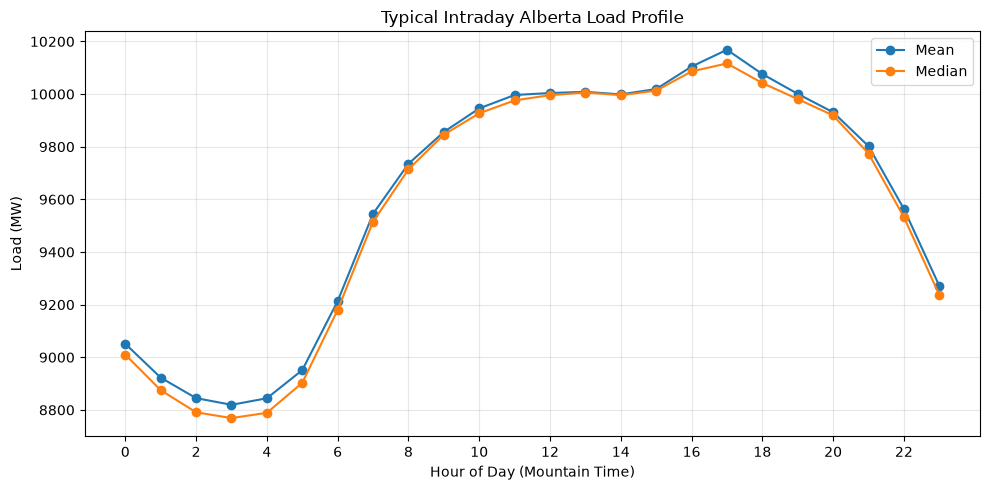

In [23]:
# ---------------------------------------------------------------------
# Summarize the typical hourly Alberta Internal Load profile
# ---------------------------------------------------------------------

hourly_load_profile = (
    master.groupby("hour_alberta")[load_col]
    .agg(["mean", "median"])
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile["median"],
    marker="o",
    label="Median",
)

ax.set_title("Typical Intraday Alberta Load Profile")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Typical Hourly Demand Profile

Alberta Internal Load follows a highly consistent daily cycle. Average demand is lowest during the overnight hours, reaching a minimum of approximately **8.82 GW** around **03:00–04:00**, before increasing rapidly through the morning. Demand remains elevated throughout the afternoon, peaking at approximately **10.17 GW** around **17:00**, and then gradually declines into the evening. The close agreement between the mean and median profiles indicates that this intraday pattern is stable and representative of typical system operation.


### 3.2 Weeday versus weekend demand

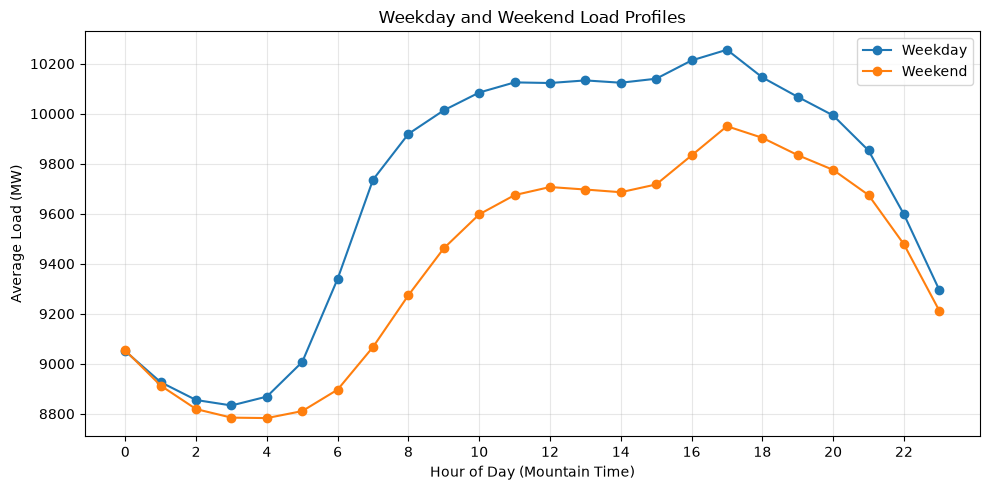

In [24]:
# ---------------------------------------------------------------------
# Compare typical weekday and weekend hourly load profiles
# ---------------------------------------------------------------------

weekday_profile = (
    master.groupby(["hour_alberta", "is_weekend"])[load_col]
    .mean()
    .unstack()
    .rename(
        columns={
            False: "Weekday",
            True: "Weekend",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

for column in weekday_profile.columns:
    ax.plot(
        weekday_profile.index,
        weekday_profile[column],
        marker="o",
        label=column,
    )

ax.set_title("Weekday and Weekend Load Profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Weekday and Weekend Demand Profiles

The overall shape of Alberta's daily demand profile is similar on weekdays and weekends, but weekday demand is consistently higher during business hours. The largest differences occur between approximately **06:00 and 18:00**, reflecting increased commercial and industrial activity on weekdays. Overnight demand is nearly identical, indicating that the weekday–weekend distinction primarily affects daytime electricity consumption rather than the system's overnight base load.


### 3.3 Seasonal demand profiles

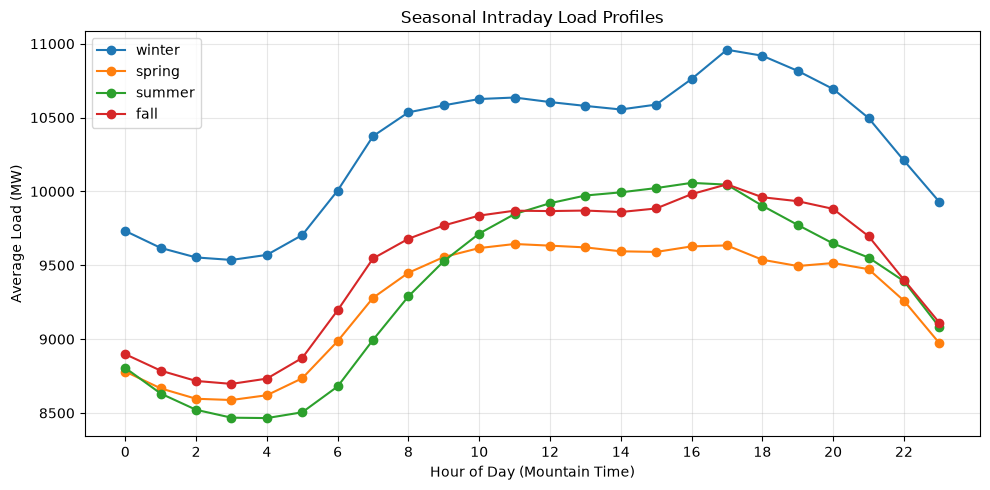

In [25]:
# ---------------------------------------------------------------------
# Compare typical hourly load profiles across seasons
# ---------------------------------------------------------------------

season_order = ["winter", "spring", "summer", "fall"]

seasonal_load_profile = (
    master.groupby(["hour_alberta", "season"])[load_col]
    .mean()
    .unstack()
    .reindex(columns=season_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

for season in seasonal_load_profile.columns:
    ax.plot(
        seasonal_load_profile.index,
        seasonal_load_profile[season],
        marker="o",
        label=season,
    )

ax.set_title("Seasonal Intraday Load Profiles")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Seasonal Demand Profiles

Electricity demand exhibits pronounced seasonal variation throughout the day. Winter consistently records the highest loads, with demand peaking at approximately **10.96 GW** around **17:00**, reflecting increased heating requirements and winter electricity consumption. Summer also exhibits elevated afternoon demand, although at lower levels than winter, while spring records the lowest demand across nearly all hours. Despite these differences in magnitude, the overall intraday demand profile remains remarkably consistent across seasons, with each exhibiting an overnight minimum, morning ramp, and late afternoon peak.


### 3.4 Typical wind, price, and import profiles

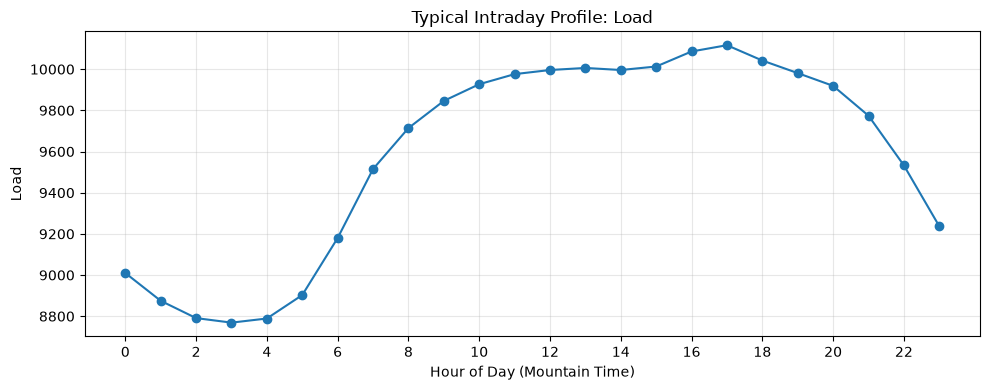

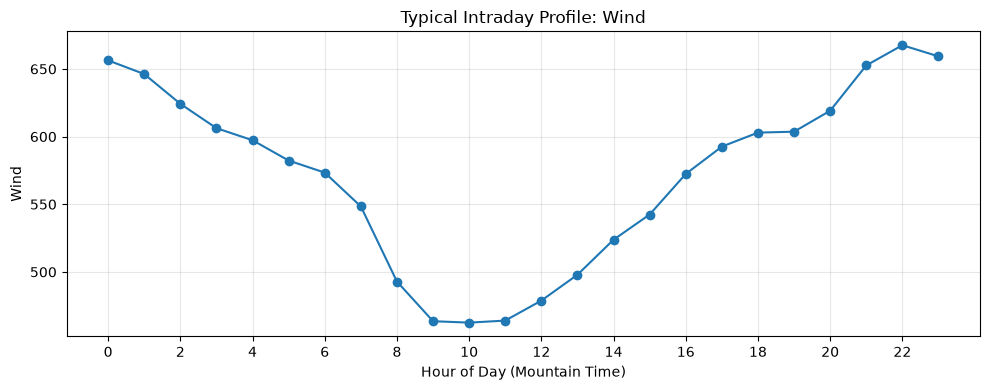

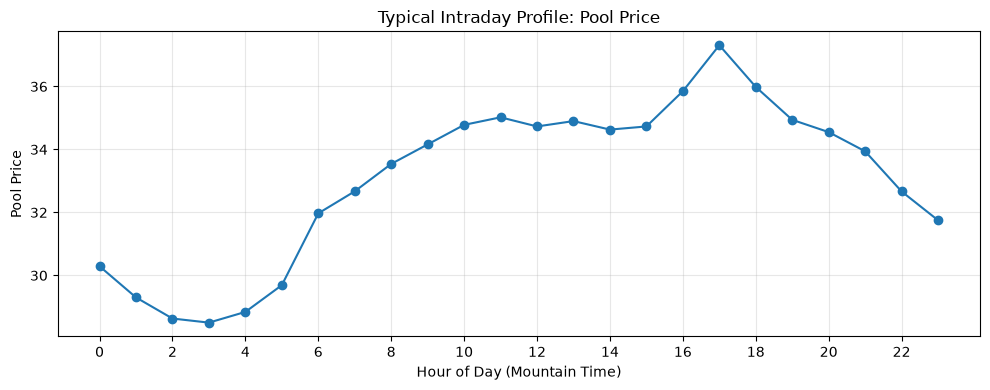

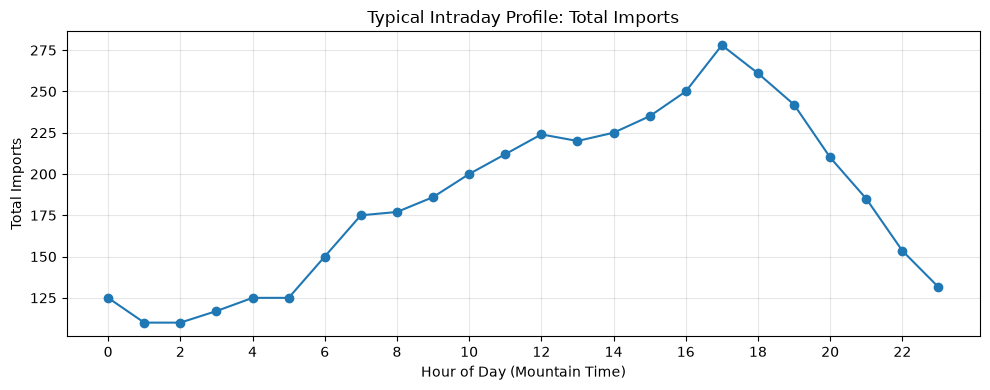

In [26]:
# ---------------------------------------------------------------------
# Compare typical hourly operating profiles for key market variables
# ---------------------------------------------------------------------

profile_variables = {
    "Load": "ail_mw",
    "Wind": "wind_system_generation",
    "Pool Price": "pool_price",
    "Total Imports": "total_imports_mw",
}

for label, column in profile_variables.items():

    profile = (
        master.groupby("hour_alberta")[column]
        .median()
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        profile.index,
        profile.values,
        marker="o",
    )

    ax.set_title(f"Typical Intraday Profile: {label}")
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Typical Profiles for Wind, Imports, and Price

Several key market variables exhibit distinct intraday patterns alongside electricity demand. Median wind generation is generally highest overnight and lowest during the daytime, partially offsetting the overnight reduction in demand. In contrast, median imports increase steadily throughout the day, peaking during the late afternoon and early evening when system demand is highest. Pool prices follow a similar pattern, remaining relatively stable overnight before increasing modestly during periods of elevated demand. Together, these profiles illustrate the regular daily interaction between demand, renewable generation, intertie utilization, and market prices under typical operating conditions.

> **Question:** is wind the primary driver of pool price during nighttime trading hours?t mean alberta exports more during the night? imports are almost exact traces of the pool price. is price driven by more by the internal bidding market, or the cost of imports?

### 3.5 Seasonal solar and wind profiles

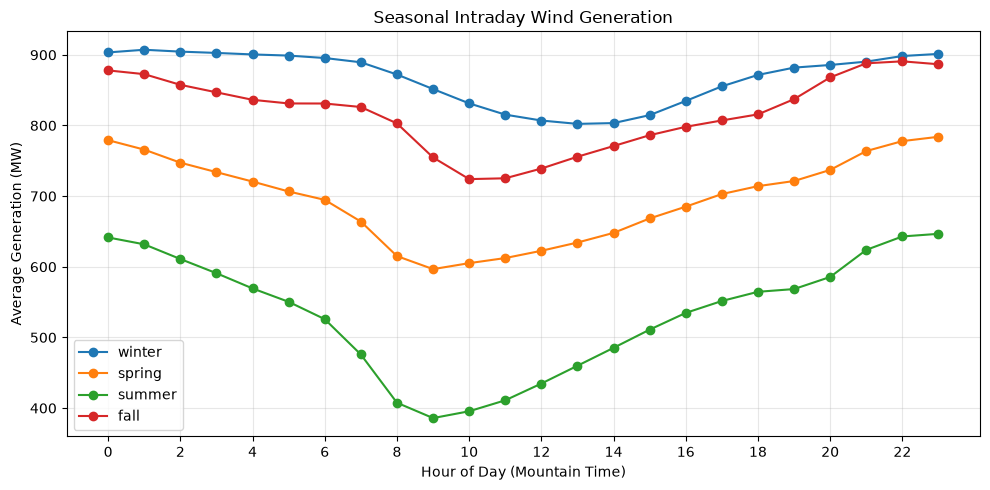

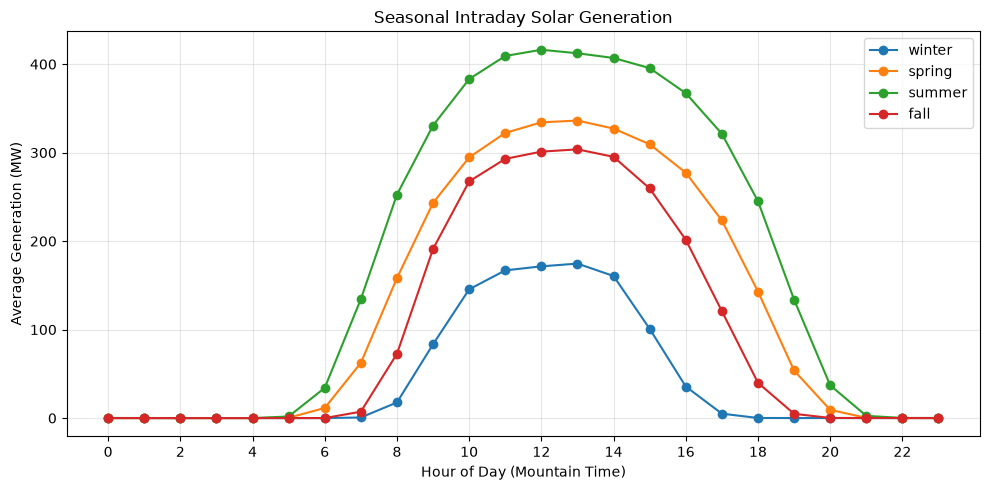

In [27]:
# ---------------------------------------------------------------------
# Compare seasonal hourly wind and solar generation profiles
# ---------------------------------------------------------------------

solar_col = "solar_system_generation"

for label, column in {
    "Wind": "wind_system_generation",
    "Solar": solar_col,
}.items():

    seasonal_profile = (
        master.groupby(["hour_alberta", "season"])[column]
        .mean()
        .unstack()
        .reindex(columns=season_order)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for season in seasonal_profile.columns:
        ax.plot(
            seasonal_profile.index,
            seasonal_profile[season],
            marker="o",
            label=season,
        )

    ax.set_title(f"Seasonal Intraday {label} Generation")
    ax.set_xlabel("Hour of Day (Mountain Time)")
    ax.set_ylabel("Average Generation (MW)")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Seasonal Wind and Solar Generation Profiles

Wind and solar generation exhibit distinct seasonal and intraday patterns. Wind generation is generally strongest during the winter months and weakest during the summer, while remaining available throughout the day. In contrast, solar generation follows the expected daylight cycle, with output peaking around midday and falling to essentially zero overnight. Seasonal differences are also pronounced: summer records the highest solar generation and the longest production window, while winter output is substantially lower and concentrated within fewer daylight hours. Together, these complementary renewable profiles contribute differently to Alberta's supply mix across both the day and the seasons.

> **Question**: the individual value of solar/wind when predicting scarcity, somehow will have to account for seasonal cycles and installed capacity. you'd assume alberta is more focused on wind, because winter is the dominant season, but that doesn't mean wind is always going to be predictive depending on the occasion. for example: solar probably won't offset commercial load, but might offset home-load on holiday where people are home all day. certain days/hours within that day might be more sensitive to cloudiness than others. wind probably has distinct "valueable" and "less valueable" periods. 

## Section 4 - How Variable Is The Market? 

Average operating profiles conceal much of the market’s risk. Electricity prices, renewable generation, outages, and system demand can exhibit asymmetric distributions, persistent periods of stress, and infrequent but operationally important extremes.  
This section examines the distributions and tails of major market variables before later notebooks investigate their drivers.

### 4.1 Distribution summary

In [28]:
# ---------------------------------------------------------------------
# Summarize the distributions of major market variables
# ---------------------------------------------------------------------

distribution_columns = {
    "Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

distribution_summary = pd.DataFrame({
    label: master[column].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    for label, column in distribution_columns.items()
}).T

distribution_summary.columns = [
    "p01",
    "p05",
    "p25",
    "median",
    "p75",
    "p95",
    "p99",
]

display(distribution_summary.round(3))

,p01,p05,p25,median,p75,p95,p99
Load,7740.000,8199.000,9024.000,9616.000,10226.000,10979.000,11402.000
Pool Price,4.596,13.620,21.350,33.230,55.100,259.960,781.125
AECO Gas,0.000,0.500,1.700,2.350,2.770,5.300,7.050
Spark Spread,-8.295,-3.285,6.395,18.715,33.915,233.727,758.258
Net Imports,-920.000,-561.000,-50.000,125.000,450.000,835.000,951.000
Total Imports,0.000,0.000,30.000,180.000,460.000,845.000,953.000
Total Exports,0.000,0.000,0.000,0.000,125.000,635.000,960.000
Total Outages,2147.300,2397.300,2981.400,3440.300,3921.300,4744.400,5636.240


#### Distribution Summary

The distributions of Alberta's major market variables differ substantially in both spread and skewness. Electricity demand and total outages occupy relatively narrow ranges, reflecting the physical constraints of the power system. In contrast, pool prices and spark spreads exhibit pronounced right tails, with the **99th percentile** far exceeding the median, indicating that extreme price events occur infrequently but can be several orders of magnitude larger than typical conditions.

Intertie flows also display asymmetric behaviour. Median net imports are positive, indicating that Alberta is more commonly a net importer than a net exporter during the study period, although both import and export distributions span a wide range of operating conditions. These distributional characteristics highlight why average operating profiles alone are insufficient for understanding market behaviour and motivate the more detailed analyses that follow.

The combination of highly skewed price distributions and relatively stable physical variables suggests that Alberta's market behaves normally most of the time but transitions rapidly into rare, high-impact operating regimes. Subsequent analyses therefore focus primarily on these extreme conditions.

### 4.2 Histograms

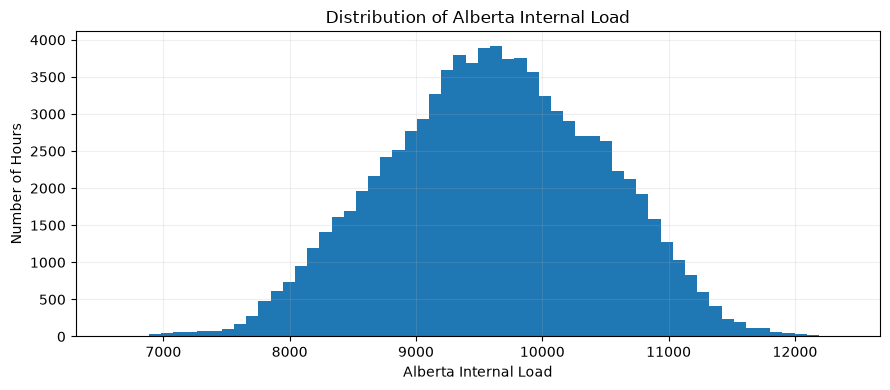

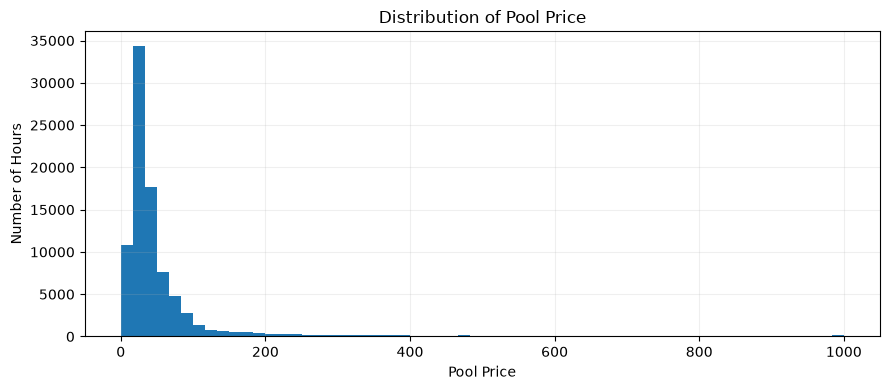

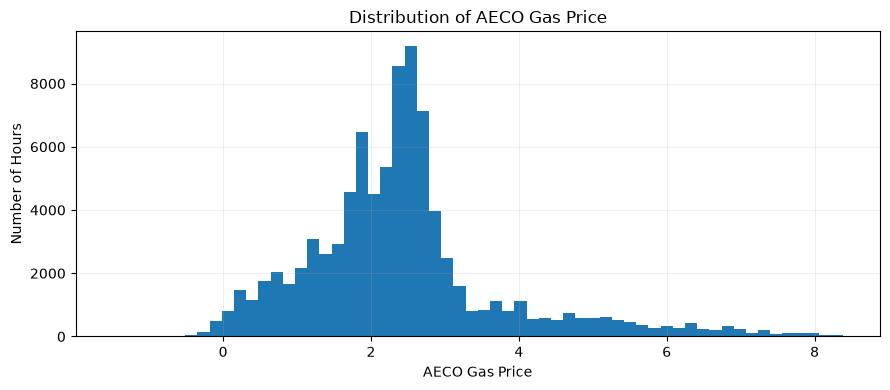

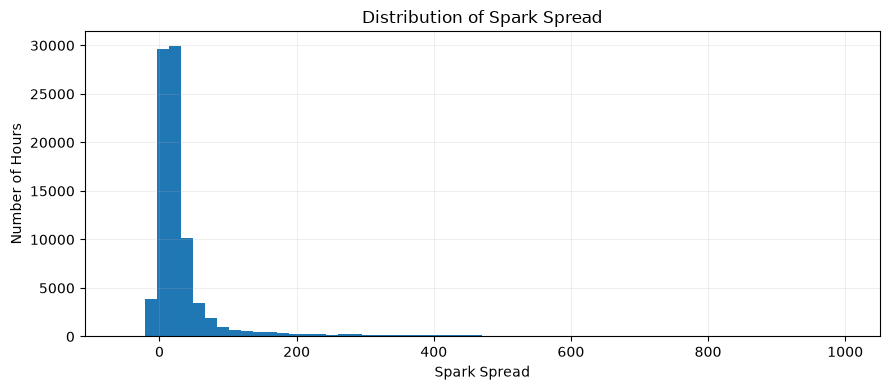

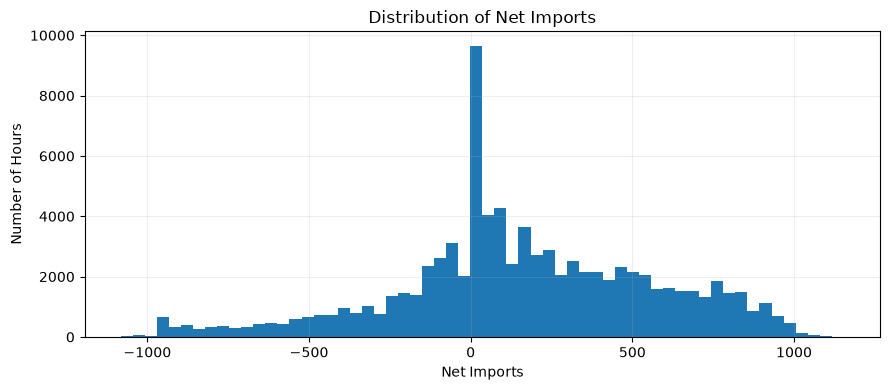

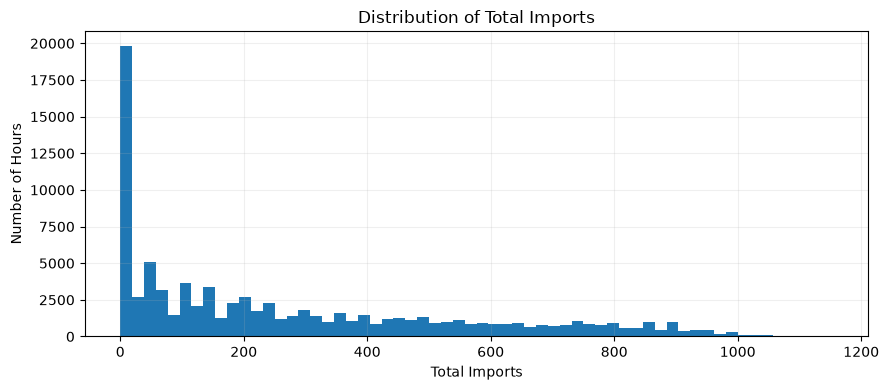

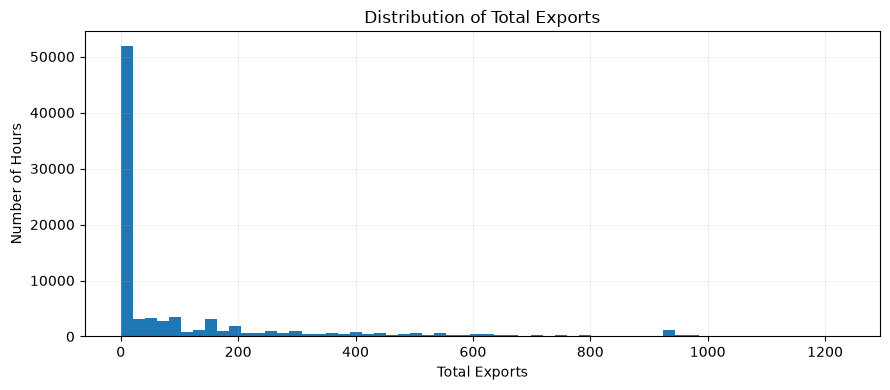

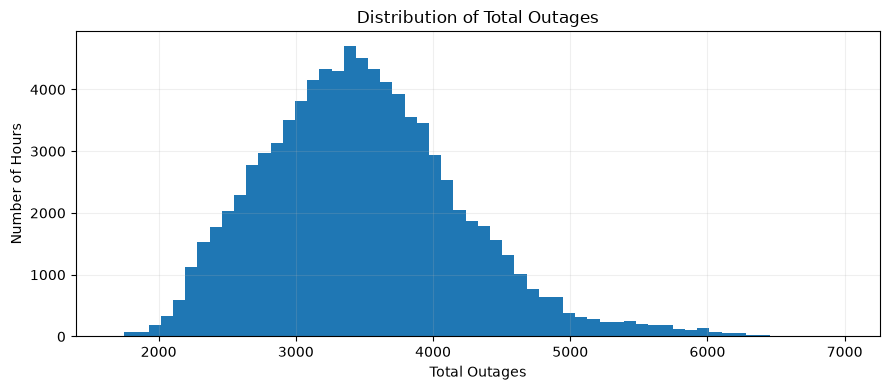

In [29]:
# ---------------------------------------------------------------------
# Visualize the empirical distributions of major market variables
# ---------------------------------------------------------------------

histogram_variables = {
    "Alberta Internal Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas Price": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

for title, column in histogram_variables.items():

    values = master[column].dropna()

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.hist(
        values,
        bins=60,
    )

    ax.set_title(f"Distribution of {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Number of Hours")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

#### Distribution Characteristics:

The histogram and summary statistics reinforce the differing distributional properties of Alberta's major market variables. Alberta Internal Load is approximately symmetric, exhibiting relatively little skewness and remaining tightly concentrated around its mean and median. Total outages also display a comparatively stable distribution, although with a modest right tail.

In contrast, Pool Price and Spark Spread are highly right-skewed, with skewness values exceeding **4.5**. Their means substantially exceed their medians, indicating that a relatively small number of extreme price events exert a large influence on average market outcomes. AECO gas prices exhibit moderate positive skewness, while total imports and exports are also asymmetric, particularly exports, which are concentrated at low values but occasionally reach very large hourly flows.

These results demonstrate that Alberta's electricity market is characterized by a mixture of relatively stable physical variables and highly volatile economic variables. This distinction motivates the use of distribution-aware methods throughout the remainder of the analysis, with greater emphasis placed on quantiles, regimes, and extreme events rather than relying solely on average behaviour.

> **Question:** why is aeco reaching values in the 4s, but not very often? what drivers that? and how detrimental is aeco gas price, to the pool price when its very high? pool price vs aeco gas price chart. imports seem to be a "most of the time we only need a little" type of variable. 


### 4.3 Price exceedance frequency

In [30]:
price_thresholds = [0, 100, 200, 500, 900]

price_exceedance = pd.DataFrame({
    'threshold': price_thresholds, 
    'hours_at_or_above': [
        (master['pool_price'] >= threshold).sum()
        for threshold in price_thresholds
    ],
    'share_of_hours_pct': [
        (master['pool_price'] >= threshold).mean() * 100
        for threshold in price_thresholds
    ],
})

price_exceedance

,threshold,hours_at_or_above,share_of_hours_pct
0,0,87665,100.000000
1,100,9605,10.956482
2,200,5411,6.172361
3,500,2292,2.614498
4,900,378,0.431187


In [31]:
price_col = 'pool_price'

annual_price_extremes = (
    master.assign(
        above_100 = master[price_col] >=100, 
        above_200 = master[price_col] >= 200,
        above_500 = master[price_col] >= 500,
        at_or_above_900 = master[price_col] >= 900,
        negative_price = master[price_col] < 0,
    )
    .groupby('year_alberta')
    .agg(
        average_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        price_volatility=(price_col, "std"),
        hours_above_100=("above_100", "sum"),
        hours_above_200=("above_200", "sum"),
        hours_above_500=("above_500", "sum"),
        hours_at_or_above_900=("at_or_above_900", "sum"),
        negative_price_hours=("negative_price", "sum"),     
    )
)

annual_price_extremes.round(2)

,average_price,median_price,price_volatility,hours_above_100,hours_above_200,hours_above_500,hours_at_or_above_900,negative_price_hours
year_alberta,,,,,,,,
2015,33.34,20.48,86.51,196,144,95,28,0
2016,18.28,15.46,12.63,8,4,2,0,0
2017,22.19,19.46,26.96,26,17,6,4,0
2018,50.35,33.25,87.22,361,208,102,29,0
2019,54.88,33.51,90.39,442,264,116,17,0
2020,46.72,33.28,92.13,306,189,102,40,0
2021,101.93,57.34,138.96,1651,871,310,42,0
2022,162.46,83.78,199.22,3179,1663,758,111,0
2023,133.63,57.20,183.84,2446,1547,606,52,0


Price Distribution and Scarcity Events:

The Alberta electricity market exhibits a highly right-skewed price distribution, characterized by relatively low prices during most hours and infrequent but severe scarcity pricing events. Across the full study period, prices exceeded $100/MWh during approximately 10.2% of all hours, while prices above $500/MWh occurred in only 2.5% of observations. Extreme price events approaching the market price cap ($900/MWh and above) were exceptionally rare, representing less than 0.5% of all hourly observations.

Annual summary statistics reveal several distinct market regimes over the study period. Between 2015 and 2017, Alberta experienced a relatively low-price environment with limited price volatility and few scarcity events. Prices increased noticeably during 2018–2020, before transitioning into a prolonged high-price regime during 2021–2023. The year 2022 was particularly notable, recording the highest average pool price ($162.46/MWh), the greatest price volatility (standard deviation of $199.22/MWh), and the largest number of scarcity events across all price thresholds. Market conditions moderated during 2024, although both average prices and volatility remained elevated relative to the earlier years.

The annual statistics also demonstrate that periods of elevated prices were accompanied by substantially greater price volatility. For example, price volatility increased from only $12.63/MWh in 2016 to $199.22/MWh in 2022, reflecting the increasing frequency and magnitude of extreme price spikes during tighter supply conditions.

The absence of any single dominant correlation suggests that Alberta prices emerge from the interaction of multiple system conditions rather than a single market driver. This motivates the multivariate analyses developed in the remaining notebooks.

> **Question:** so prices today are generally higher than they used to be, even though renewables are offered for free, and coal/gas would've been priced highly? i suppose that was before alberta beacme a true "free market bidding" province. legislation was still in place. again going back to gas-pool price correlation, the russia-ukraine war probably had alot to do with those price spikes. i wonder if alot of the $3-5 prices AECO hours were during 2022-2023. Is system flexibility and robustness more important for pool prices than the marginal cost of individual technologies? for example, wind sells at zero, gas at a price, and yet prices have gone up even though wind has gone up, and alberta hasn't had trouble keeping up with demand, installed capacity has otupaced the demand rise. weird

## Section 5 - When Is The Market Stressed?

Extreme prices and scarcity conditions are not distributed evenly through time. Their concentration by year, season, month, and hour provides an initial indication of when Alberta’s system is most vulnerable.  
This section describes the timing and frequency of stress events without yet attempting to identify their causal drivers.

### 5.1 - Confirm the scarcity definition and base rate

In [32]:
# ---------------------------------------------------------------------
# Confirm the scarcity definition and overall event frequency
# ---------------------------------------------------------------------

scarcity_col = master[price_col] >= 200

scarcity_summary = pd.Series({
    "total_hours": len(master),
    "scarcity_hours": scarcity_col.sum(),
    "scarcity_rate_pct": scarcity_col.mean() * 100,
})

display(scarcity_summary.round(2))

total_hours          87665.00
scarcity_hours        5411.00
scarcity_rate_pct        6.17
dtype: float64

In [33]:
# ---------------------------------------------------------------------
# Summarize scarcity frequency by calendar year
# ---------------------------------------------------------------------

scarcity_by_year = (
    master
    .assign(scarcity=scarcity_col)
    .groupby("year_alberta")
    .agg(
        observed_hours=("scarcity", "size"),
        scarcity_hours=("scarcity", "sum"),
        scarcity_rate=("scarcity", "mean"),
        average_price=(price_col, "mean"),
    )
)

scarcity_by_year["scarcity_rate_pct"] = (
    scarcity_by_year["scarcity_rate"] * 100
)

display(scarcity_by_year.round(3))

,observed_hours,scarcity_hours,scarcity_rate,average_price,scarcity_rate_pct
year_alberta,,,,,
2015,8760,144,0.016,33.338,1.644
2016,8784,4,0.000,18.279,0.046
2017,8760,17,0.002,22.186,0.194
2018,8760,208,0.024,50.348,2.374
2019,8760,264,0.030,54.880,3.014
2020,8784,189,0.022,46.716,2.152
2021,8760,871,0.099,101.932,9.943
2022,8760,1663,0.190,162.463,18.984
2023,8760,1547,0.177,133.628,17.660


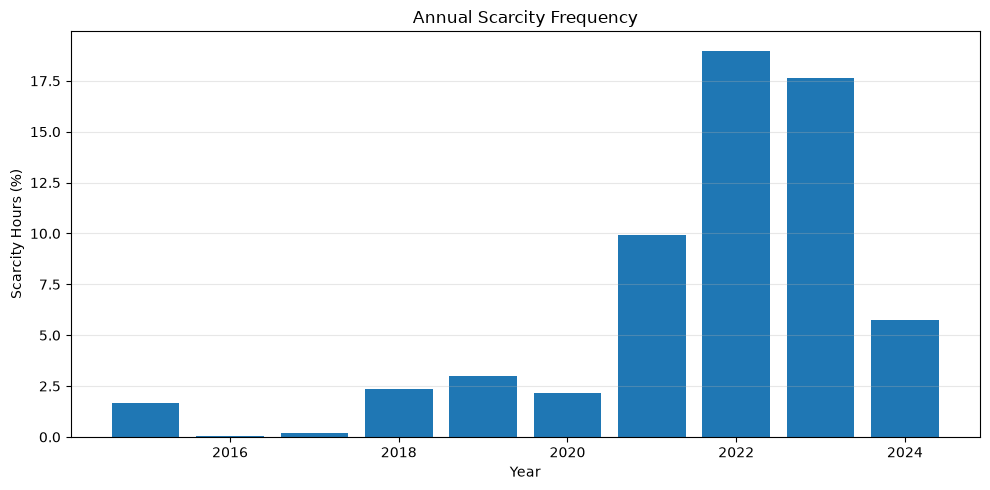

In [34]:
# ---------------------------------------------------------------------
# Visualize annual scarcity frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    scarcity_by_year.index,
    scarcity_by_year["scarcity_rate_pct"],
)

ax.set_title("Annual Scarcity Frequency")
ax.set_xlabel("Year")
ax.set_ylabel("Scarcity Hours (%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Scarcity Definition and Base Rate

Throughout this project, a **scarcity hour** is defined as any hour in which the Alberta pool price is **at least \$200/MWh**. Using this definition, scarcity occurred during **5,411** of the **87,665** observed hours, representing approximately **6.2%** of the study period.

Scarcity was not distributed evenly across time. Prior to 2021, scarcity rates remained below **3.1%** in every year and were almost negligible during 2016 and 2017. Conditions changed markedly beginning in **2021**, when nearly **10%** of all hours met the scarcity definition. Scarcity peaked in **2022**, when almost **19%** of the year experienced prices of at least **\$200/MWh**, before remaining elevated in **2023** and moderating during **2024**.

These results demonstrate that scarcity in Alberta is episodic rather than persistent. Most years experience relatively few scarcity events, while periods of sustained market stress can substantially increase both the frequency of scarcity hours and annual average prices.

### 5.3 Scarcity by month

In [35]:
# ---------------------------------------------------------------------
# Summarize scarcity frequency by calendar month
# ---------------------------------------------------------------------

month_order = [
    "january", "february", "march", "april",
    "may", "june", "july", "august",
    "september", "october", "november", "december",
]

scarcity_by_month = (
    master
    .assign(scarcity=scarcity_col)
    .groupby("month_name_alberta")
    .agg(
        observed_hours=("scarcity", "size"),
        scarcity_hours=("scarcity", "sum"),
        scarcity_rate=("scarcity", "mean"),
        average_price=(price_col, "mean"),
    )
    .reindex(month_order)
)

scarcity_by_month["scarcity_rate_pct"] = (
    scarcity_by_month["scarcity_rate"] * 100
)

display(scarcity_by_month.round(3))

,observed_hours,scarcity_hours,scarcity_rate,average_price,scarcity_rate_pct
month_name_alberta,,,,,
january,7440,445,0.060,72.209,5.981
february,6792,436,0.064,70.791,6.419
march,7430,344,0.046,57.597,4.630
april,7200,341,0.047,57.961,4.736
may,7440,432,0.058,65.150,5.806
june,7200,539,0.075,76.716,7.486
july,7440,564,0.076,73.116,7.581
august,7440,585,0.079,79.289,7.863
september,7200,464,0.064,70.265,6.444


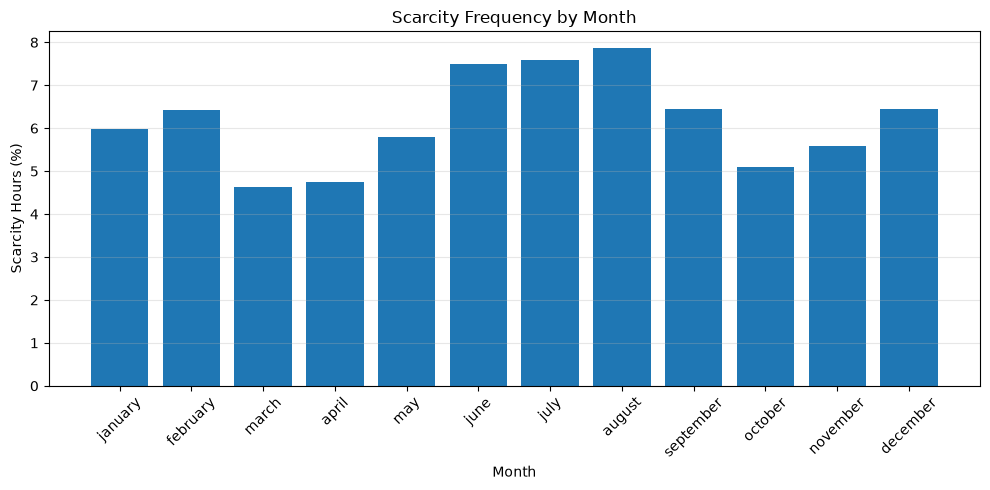

In [36]:
# ---------------------------------------------------------------------
# Visualize seasonal patterns in scarcity frequency
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    scarcity_by_month.index,
    scarcity_by_month["scarcity_rate_pct"],
)

ax.set_title("Scarcity Frequency by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Scarcity Hours (%)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Scarcity by Month

Scarcity events occur throughout the year but exhibit a clear seasonal pattern. The highest scarcity frequencies occur during the summer months, peaking in **August (7.9%)**, followed closely by **July (7.6%)** and **June (7.5%)**. Winter months also experience elevated scarcity rates, with **February (6.4%)**, **December (6.4%)**, and **January (6.0%)** all exceeding the overall study average.

In contrast, spring exhibits the lowest frequency of scarcity events. **March (4.6%)** and **April (4.7%)** record the fewest scarcity hours and the lowest average pool prices of any months in the year. Overall, the results suggest that Alberta's electricity market experiences the greatest operational stress during periods of high summer demand and winter heating demand, while the shoulder seasons are generally characterized by more favorable supply-demand conditions.

> **Question:** If summary months generate more scarcity, does that reflect the baseline alberta is designed for (winter). if so "unexpected" or "unequipped" scenarios effect scarcity chances more than certain conditions? what are the unexpected conditions for alberta?

### 5.4 Scarcity by hour of day

In [41]:
scarcity_by_hour = (
    master
    .assign(scarcity=master["pool_price"].ge(200))
    .groupby("hour_alberta")
    .agg(
        observed_hours=("scarcity", "size"),
        scarcity_hours=("scarcity", "sum"),
        scarcity_rate=("scarcity", "mean"),
        average_price=("pool_price", "mean"),
        median_price=("pool_price", "median"),
    )
)

scarcity_by_hour["scarcity_rate_pct"] = (
    scarcity_by_hour["scarcity_rate"] * 100
)

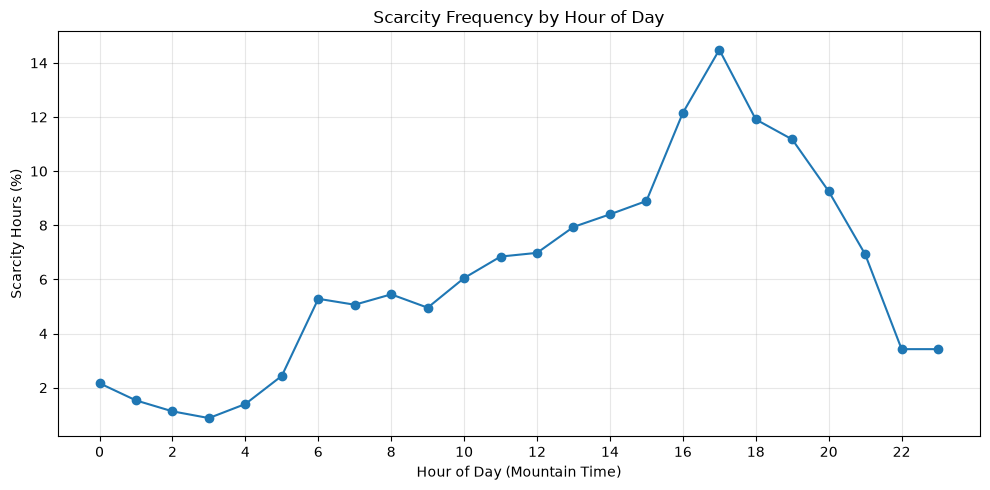

In [42]:
# ---------------------------------------------------------------------
# Visualize the intraday distribution of scarcity events
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    scarcity_by_hour.index,
    scarcity_by_hour["scarcity_rate_pct"],
    marker="o",
)

ax.set_title("Scarcity Frequency by Hour of Day")
ax.set_xlabel("Hour of Day (Mountain Time)")
ax.set_ylabel("Scarcity Hours (%)")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Scarcity by Hour of Day

Scarcity events exhibit a pronounced intraday pattern. Scarcity frequency is lowest during the overnight hours, falling below **2%** between **01:00** and **05:00**, before increasing steadily through the morning and afternoon. The highest incidence of scarcity occurs during the late afternoon and early evening, peaking at **17:00**, when approximately **14.5%** of all observed hours satisfy the scarcity definition. Elevated scarcity rates persist through **18:00–20:00** before declining into the evening.

This pattern closely aligns with Alberta's daily demand cycle and indicates that market stress is concentrated during periods of highest system load. The corresponding increase in average hourly pool prices reinforces the close relationship between elevated demand and scarcity conditions, a relationship that will be examined in greater detail in subsequent analyses.

> **Quesiton:** Scarcity by hour of day follows the exact same shape as pool price. evening load spikes. 

### 5.5 Year-month stress map

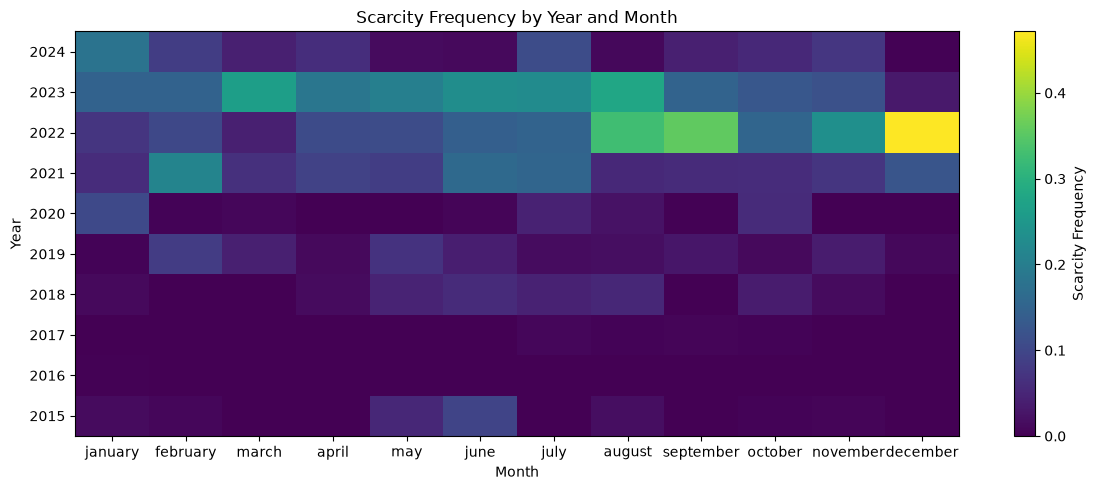

In [ ]:
# ---------------------------------------------------------------------
# Visualize the monthly evolution of scarcity frequency
# ---------------------------------------------------------------------

scarcity_calendar = (
    master
    .assign(scarcity=scarcity_col)
    .groupby(["year_alberta", "month_alberta"])["scarcity"]
    .mean()
    .unstack()
    .reindex(columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 5))

image = ax.imshow(
    scarcity_calendar,
    aspect="auto",
    origin="lower",
)

ax.set_title("Scarcity Frequency by Year and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticks(range(12))
ax.set_xticklabels(month_order)

ax.set_yticks(range(len(scarcity_calendar.index)))
ax.set_yticklabels(scarcity_calendar.index)

plt.colorbar(
    image,
    ax=ax,
    label="Scarcity Frequency",
)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------
# Display monthly scarcity frequency by year
# ---------------------------------------------------------------------

scarcity_calendar_pct = (
    scarcity_calendar * 100
)

scarcity_calendar_pct.columns = month_order

display(scarcity_calendar_pct.round(2))

,january,february,march,april,may,june,july,august,september,october,november,december
year_alberta,,,,,,,,,,,,
2015,1.34,0.74,0.00,0.00,5.24,9.58,0.13,1.75,0.00,0.40,0.55,0.00
2016,0.27,0.00,0.00,0.00,0.00,0.00,0.13,0.13,0.00,0.00,0.00,0.00
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.81,0.40,0.56,0.40,0.14,0.00
2018,1.21,0.00,0.00,1.39,4.70,5.83,4.57,5.24,0.14,3.63,1.39,0.13
2019,0.40,8.33,4.17,1.11,6.85,4.03,1.48,1.75,2.78,1.21,3.61,0.94
2020,10.48,0.43,0.81,0.00,0.00,0.69,4.44,2.28,0.28,5.78,0.14,0.13
2021,6.05,21.28,6.59,9.31,8.60,16.11,15.32,5.38,5.83,6.05,7.35,12.50
2022,7.26,10.27,4.17,10.69,11.02,14.31,15.05,32.66,35.69,15.46,23.44,47.18
2023,14.92,14.88,26.38,18.61,20.30,23.06,22.85,27.96,15.00,12.77,11.65,3.23


#### Monthly Evolution of Scarcity

The year-by-month heatmap highlights that scarcity is concentrated within relatively short periods rather than being evenly distributed over time. Prior to **2021**, scarcity events were generally infrequent and isolated, with only occasional months experiencing elevated stress. Beginning in **2021**, scarcity became both more frequent and more persistent across consecutive months.

The most severe period occurred during **2022** and **2023**. Several months in **2022** experienced scarcity rates exceeding **20%**, including **August (32.7%)**, **September (35.7%)**, **November (23.4%)**, and **December (47.2%)**, indicating that nearly half of all hours in December satisfied the scarcity definition. Elevated scarcity continued through much of **2023**, although it was distributed more broadly across the year rather than concentrated in only a few months. Conditions moderated during **2024**, though several months still exhibited higher scarcity frequencies than were typical before 2021.

Overall, the heatmap demonstrates that Alberta's periods of market stress occur in distinct clusters spanning weeks or months rather than as isolated high-price events, suggesting the influence of persistent system conditions that will be investigated in subsequent analyses.

## Section 6 - What Relationships Stand Out?

The preceding sections established how the market changes through time and when stressed conditions occur. This section examines a limited set of descriptive relationships between price, demand, renewable output, gas, imports, and outages.  
These results are exploratory. Contemporaneous relationships may reflect response, common causation, or reverse causality and should not yet be interpreted as forecasting relationships.

### 6.1 Correlation table

**Pearson correlation** - measures linear relationships. If the relationship looks like a straight line, the pearson correlation is high. Often leads to understated relationships.

**Spearman correlation** - ignores the actual values. It asks "when variable A increases, does variable B generally increase?", then converts everything to ranks. 

In [ ]:
# ---------------------------------------------------------------------
# Construct variables for relationship analysis
# ---------------------------------------------------------------------

net_load = (
    master["ail_mw"]
    - master["wind_system_generation"]
    - master["solar_system_generation"]
).rename("net_load")


relationship_df = (
    master[
        [
            "pool_price",
            "ail_mw",
            "wind_system_generation",
            "solar_system_generation",
            "hydro_system_generation",
            "total_system_generation",
            "total_imports_mw",
            "total_outage_mw",
            "gas_price",
        ]
    ]
    .join(net_load)
    .assign(
        renewable_share=lambda df: (
            (
                df["wind_system_generation"]
                + df["solar_system_generation"]
                + df["hydro_system_generation"]
            )
            / df["total_system_generation"]
        ),
    )
    .rename(
        columns={
            "pool_price": "price",
            "ail_mw": "load",
            "wind_system_generation": "wind",
            "total_imports_mw": "imports",
            "total_outage_mw": "outages",
            "gas_price": "gas",
        }
    )
    [
        [
            "price",
            "load",
            "net_load",
            "wind",
            "renewable_share",
            "imports",
            "outages",
            "gas",
        ]
    ]
)


# ---------------------------------------------------------------------
# Compute Pearson and Spearman correlations
# ---------------------------------------------------------------------

pearson_corr = relationship_df.corr(method="pearson")
spearman_corr = relationship_df.corr(method="spearman")


# ---------------------------------------------------------------------
# Display correlations with pool price
# ---------------------------------------------------------------------

print("Pearson correlation with price:")

display(
    pearson_corr["price"]
    .sort_values(ascending=False)
    .to_frame("pearson")
)

print("Spearman correlation with price:")

display(
    spearman_corr["price"]
    .sort_values(ascending=False)
    .to_frame("spearman")
)

Pearson correlation with price:


,pearson
price,1.000000
net_load,0.332568
load,0.260430
gas,0.250029
imports,0.243115
outages,0.116812
wind,-0.169682
renewable_share,-0.199550


Spearman correlation with price:


,spearman
price,1.000000
imports,0.497703
net_load,0.457801
load,0.438992
gas,0.391449
outages,0.100029
wind,-0.130323
renewable_share,-0.278192


#### Correlation Summary

The correlation analysis highlights several intuitive relationships while illustrating that no single variable explains Alberta's electricity prices in isolation. Both Pearson and Spearman correlations identify **net load**, **electricity demand**, **natural gas prices**, and **imports** as the variables most strongly associated with higher pool prices. Among these, imports exhibit the strongest monotonic relationship with price (Spearman = **0.50**), suggesting that elevated imports frequently coincide with periods of market stress.

Renewable generation exhibits the opposite relationship. Wind generation and the renewable share of total generation are both negatively correlated with pool prices, indicating that greater renewable availability is generally associated with lower prices. Total outages display only a relatively weak positive correlation with price, suggesting that outage volume alone is insufficient to explain scarcity conditions.

The stronger Spearman correlations relative to Pearson for several variables indicate that many of these relationships are monotonic but not strictly linear, reflecting the threshold-driven and regime-dependent behaviour of Alberta's electricity market. As noted at the beginning of this section, these contemporaneous relationships should not be interpreted as causal or predictive, but rather as an initial guide to the variables that warrant more detailed investigation.

### 6.2 Binned price relationships

In [ ]:
# ---------------------------------------------------------------------
# Define a reusable decile relationship summary
# ---------------------------------------------------------------------

def decile_relationship(
    data,
    feature,
    target,
    q=10,
):
    sample = data[[feature, target]].dropna().copy()

    sample["feature_decile"] = pd.qcut(
        sample[feature],
        q=q,
        labels=False,
        duplicates="drop",
    )

    summary = (
        sample.groupby("feature_decile")
        .agg(
            n_hours=(target, "size"),
            average_feature=(feature, "mean"),
            median_target=(target, "median"),
            average_target=(target, "mean"),
            p90_target=(target, lambda series: series.quantile(0.90)),
        )
    )

    return summary

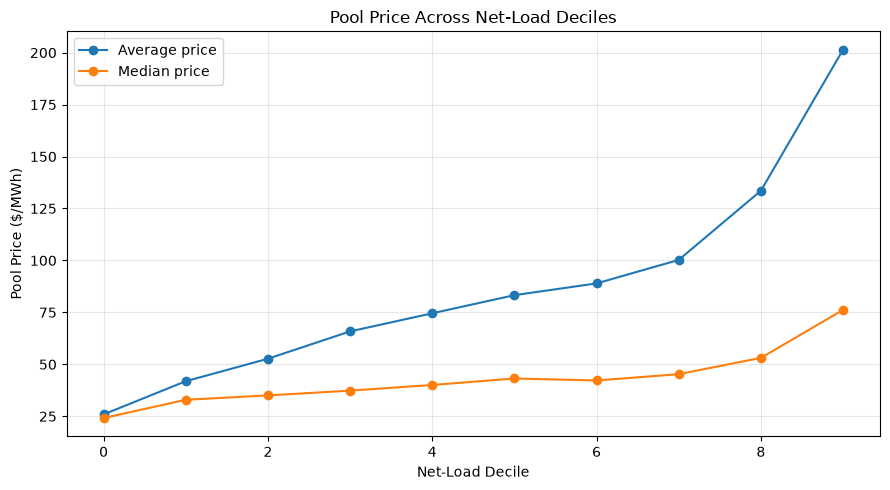

In [ ]:
# ---------------------------------------------------------------------
# Visualize pool-price behaviour across net-load deciles
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["average_target"],
    marker="o",
    label="Average price",
)

ax.plot(
    netload_price_deciles.index,
    netload_price_deciles["median_target"],
    marker="o",
    label="Median price",
)

ax.set_title("Pool Price Across Net-Load Deciles")
ax.set_xlabel("Net-Load Decile")
ax.set_ylabel("Pool Price ($/MWh)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

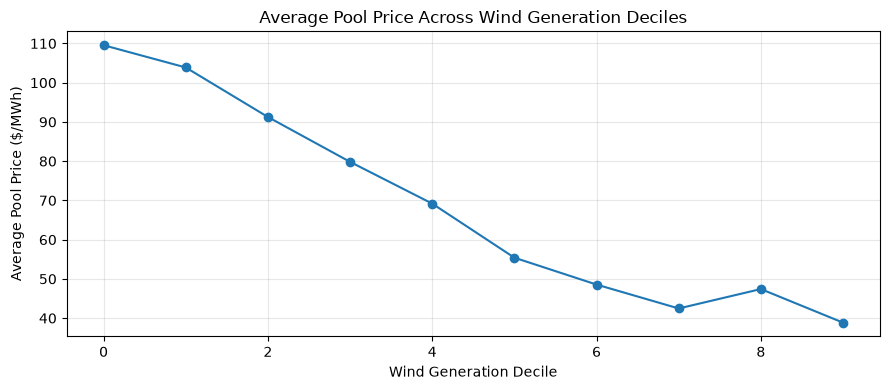

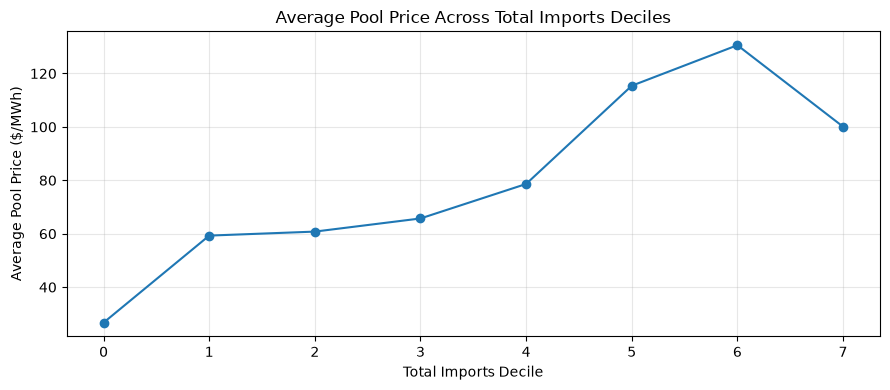

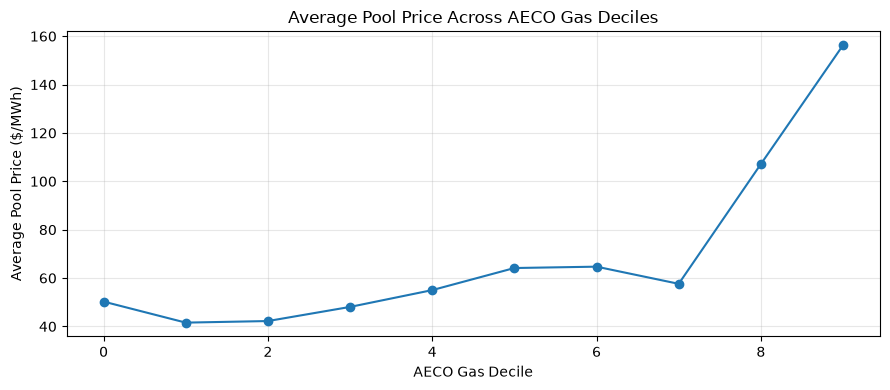

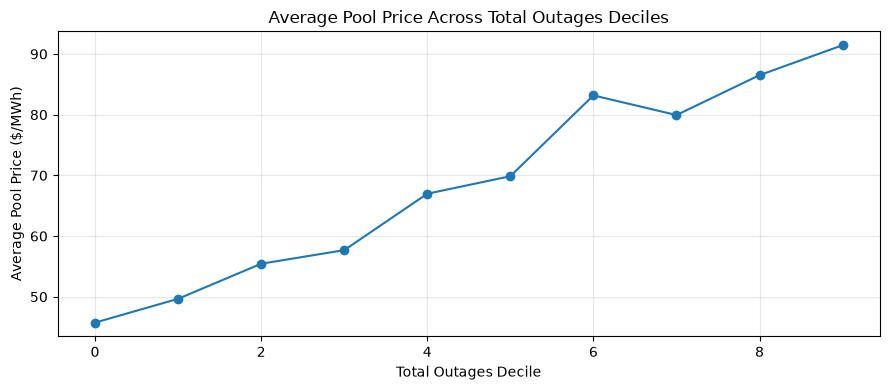

In [ ]:
# ---------------------------------------------------------------------
# Compare pool-price behaviour across selected feature deciles
# ---------------------------------------------------------------------

features_to_test = {
    "Wind Generation": "wind_system_generation",
    "Total Imports": "total_imports_mw",
    "AECO Gas": "gas_price",
    "Total Outages": "total_outage_mw",
}

decile_results = {}

for label, feature in features_to_test.items():

    summary = decile_relationship(
        master,
        feature,
        "pool_price",
    )

    decile_results[label] = summary

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(
        summary.index,
        summary["average_target"],
        marker="o",
    )

    ax.set_title(f"Average Pool Price Across {label} Deciles")
    ax.set_xlabel(f"{label} Decile")
    ax.set_ylabel("Average Pool Price ($/MWh)")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Price Response Across Variable Deciles

The decile analysis reveals that Alberta's electricity prices respond nonlinearly to several key market variables. The clearest relationship is observed for **net load**, where average pool prices increase steadily from approximately **\$26/MWh** in the lowest decile to more than **\$200/MWh** in the highest decile. The upper tail becomes increasingly pronounced as well, with the 90th percentile price rising from **\$49/MWh** to more than **\$650/MWh** across the same range. This indicates that periods of high net load are associated not only with higher typical prices but also with a much greater likelihood of extreme price events.

The remaining variables exhibit similar, though less pronounced, patterns. Average pool prices generally increase with **natural gas prices**, **total outages**, and **imports**, while increasing **wind generation** is associated with progressively lower prices. Among these variables, imports display the strongest apparent threshold behaviour, with average prices rising rapidly once Alberta enters the upper import deciles. Collectively, these results reinforce the conclusion that Alberta's electricity market is characterized by nonlinear relationships, where market conditions change relatively gradually through much of the operating range before deteriorating rapidly under more extreme system conditions.

> **Question:** interesting that aeco is really not correlated with pool price until near the end. t maybe there is some truth to AECO can become a major predictor when it's higher than normal, but maybe not when its in the normal band. also interesting why pool price-imports correlation goes down at the very highest import bands. 

### 6.3 Scatterplots with controlled visual ranges

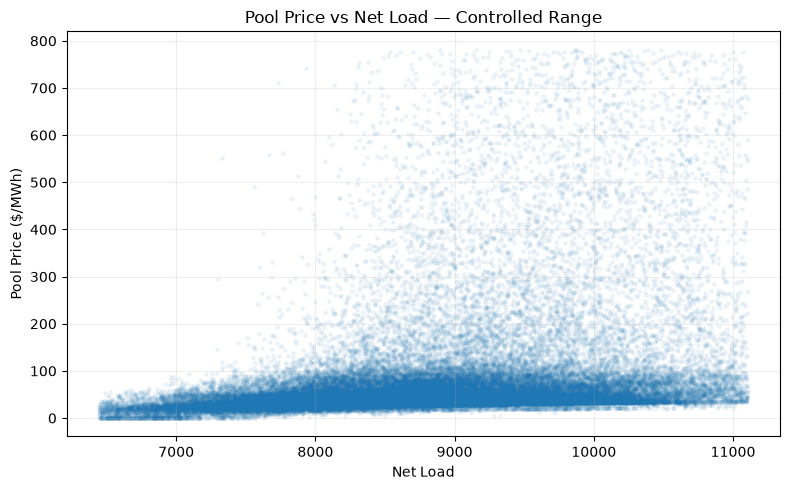

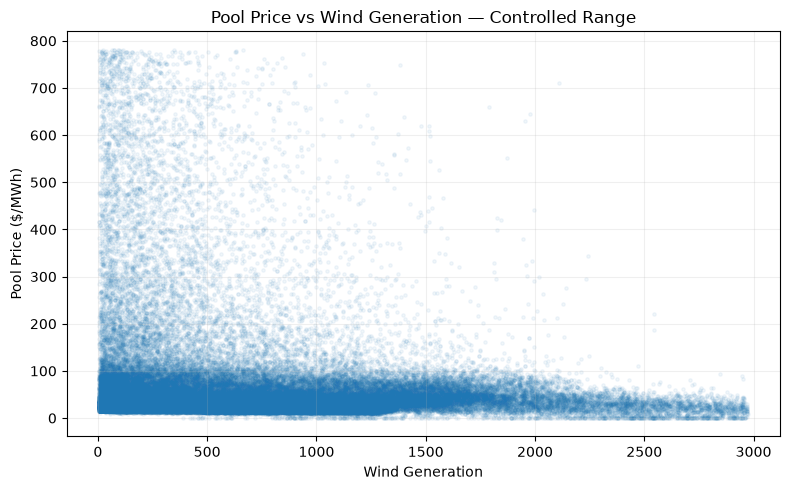

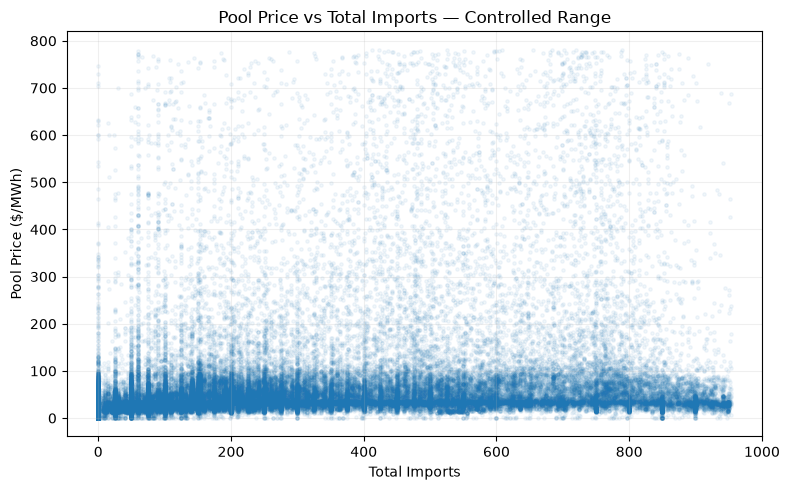

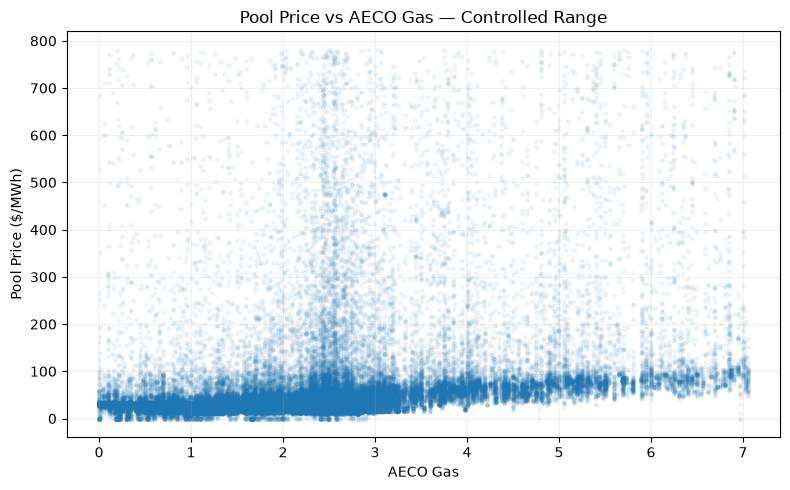

In [ ]:
# ---------------------------------------------------------------------
# Visualize price relationships within controlled display ranges
# ---------------------------------------------------------------------

scatter_features = {
    "Net Load": "net_load",
    "Wind Generation": "wind",
    "Total Imports": "imports",
    "AECO Gas": "gas",
}

scatter_samples = {}

price_upper_limit = relationship_df["price"].quantile(0.99)

for label, column in scatter_features.items():

    feature_lower_limit = relationship_df[column].quantile(0.01)
    feature_upper_limit = relationship_df[column].quantile(0.99)

    sample = (
        relationship_df.loc[
            relationship_df["price"].le(price_upper_limit)
            & relationship_df[column].between(
                feature_lower_limit,
                feature_upper_limit,
            ),
            [column, "price"],
        ]
        .dropna()
        .copy()
    )

    scatter_samples[label] = sample

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        sample[column],
        sample["price"],
        alpha=0.06,
        s=6,
    )

    ax.set_title(f"Pool Price vs {label} — Controlled Range")
    ax.set_xlabel(label)
    ax.set_ylabel("Pool Price ($/MWh)")
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

#### Scatterplot Relationships

The controlled-range scatterplots reinforce the nonlinear relationships observed in the correlation and decile analyses. **Net load** exhibits the clearest positive association with pool price, with prices remaining relatively moderate across much of the operating range before increasing rapidly at the highest net-load levels. This pattern is consistent with Alberta's energy-only market, where prices tend to rise sharply as available supply becomes increasingly scarce.

The remaining variables display similar but less direct relationships. Higher **wind generation** is generally associated with lower pool prices, although substantial price variation remains at all wind output levels, indicating that wind alone does not determine market outcomes. **Total imports** are associated with progressively higher prices, particularly at moderate to high import levels, suggesting that Alberta increasingly relies on imports during periods of system stress. **AECO natural gas prices** also exhibit a positive relationship with electricity prices, with the highest gas-price deciles corresponding to substantially higher average pool prices.

Overall, the scatterplots illustrate that Alberta's electricity prices are influenced by multiple interacting system conditions rather than any single explanatory variable. The wide dispersion of prices for a given value of each feature further suggests that market outcomes are highly state-dependent, motivating the multivariate and predictive analyses developed in later notebooks.



Hypothesis: 
- Net load dominates scarcity
- Imports respond to stress
- Flexibility > installed capacity
- Threshold behaviour
- Gas only matters in stressed markets
- Seasonal feature importance
- Regime behaviour


In [44]:
annual_analysis_coverage = (
    master.groupby("year_alberta")
    .agg(
        first_timestamp=("timestamp_utc", "min"),
        last_timestamp=("timestamp_utc", "max"),
        observed_hours=("timestamp_utc", "size"),
    )
)

annual_analysis_coverage["expected_hours"] = (
    annual_analysis_coverage.index.map(
        lambda year: 8784 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 8760
    )
)

annual_analysis_coverage["coverage_pct"] = (
    annual_analysis_coverage["observed_hours"]
    / annual_analysis_coverage["expected_hours"]
    * 100
)

annual_analysis_coverage

,first_timestamp,last_timestamp,observed_hours,expected_hours,coverage_pct
year_alberta,,,,,
2015,2015-01-01 07:00:00+00:00,2016-01-01 06:00:00+00:00,8760,8760,100.00000
2016,2016-01-01 07:00:00+00:00,2017-01-01 06:00:00+00:00,8784,8784,100.00000
2017,2017-01-01 07:00:00+00:00,2018-01-01 06:00:00+00:00,8760,8760,100.00000
2018,2018-01-01 07:00:00+00:00,2019-01-01 06:00:00+00:00,8760,8760,100.00000
2019,2019-01-01 07:00:00+00:00,2020-01-01 06:00:00+00:00,8760,8760,100.00000
2020,2020-01-01 07:00:00+00:00,2021-01-01 06:00:00+00:00,8784,8784,100.00000
2021,2021-01-01 07:00:00+00:00,2022-01-01 06:00:00+00:00,8760,8760,100.00000
2022,2022-01-01 07:00:00+00:00,2023-01-01 06:00:00+00:00,8760,8760,100.00000
2023,2023-01-01 07:00:00+00:00,2024-01-01 06:00:00+00:00,8760,8760,100.00000
